# 4.1 — inspect the HMM fits

Per-session segmentations and summary statistics for whatever `4.0_hmm_fit.ipynb` has
produced. **Nothing here refits** — the decoded states are in the pickles, so this runs in
seconds and works while a fitting job is still going.

Panels are variable-aware: whisker ME is drawn as a trace, lick counts as event ticks,
because a count series plotted as a line is unreadable at 60 Hz.

All plotting lives in `hmm_plots.py`.

In [1]:
""" IMPORTS """
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hmm_functions as H
import hmm_plots as P

%matplotlib inline

ERROR:2026-08-18 18:56:01,453:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/ines/miniconda3/envs/iblenv/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


## Configuration — must match the run you want to look at

In [48]:
# ==========================================================================
#                                RUN CODE
# ==========================================================================

prefix = '/home/ines/repositories/representation_learning_variability/'

data_path = prefix + 'paper-individuality/data/design_matrices/'
fps = 60.0

# same block as in 5.0 -- keep these in step
VARIABLES = [
    dict(var='whisker_me', model='gaussian', zsc=True,  method='kmeans'),
    dict(var='Lick count', model='poisson',  zsc=False, method='prior'),
]
num_states = 2
num_train_batches = 5
fit_method = 'em'
kappa = 0.0
min_dwell_ms = 167.

# an external duration reference, where one exists. For whisker ME the model-free
# changepoint duration is ~450 ms (IQR 379-550); there is no such anchor for licking.
ANCHOR = {'whisker_me': 450.}

def paths_for(spec):
    tag = f"{num_train_batches}_{spec['model']}_{spec['method']}_{fit_method}_" \
          f"zsc_{spec['zsc']}_k{int(kappa)}_s{num_states}/"
    save = prefix + 'paper-individuality/data/hmm/fits/' + tag
    csv = os.path.join(save, f"assessments_{spec['var']}.csv")
    return save, csv

for spec in VARIABLES:
    save_path, csv_path = paths_for(spec)
    n = len(P.available_sessions(save_path, spec['var'])) if os.path.exists(save_path) else 0
    print(f"  {spec['var']:14s} {spec['model']:10s} {n:4d} fits   {save_path}")

  whisker_me     gaussian    342 fits   /home/ines/repositories/representation_learning_variability/paper-individuality/data/hmm/fits/5_gaussian_kmeans_em_zsc_True_k0_s2/
  Lick count     poisson     342 fits   /home/ines/repositories/representation_learning_variability/paper-individuality/data/hmm/fits/5_poisson_prior_em_zsc_False_k0_s2/


## Which sessions are finished

In [49]:
# pick the variable to inspect
spec = VARIABLES[1]
var, model = spec['var'], spec['model']
save_path, csv_path = paths_for(spec)

sessions_available = P.available_sessions(save_path, var)
print(f'Found {len(sessions_available)} finished sessions for {var} ({model}).')

# rebuilt from the pickles, so it is complete even if the run was interrupted
df = H.assessments_from_pickles(save_path, var)
cols = [c for c in ['mouse','eid','n_frames','n_segments','median_dwell_ms',
                    'occupancy_state1','level_low','level_high','raw_ll_per_frame',
                    'bits_LL','fit_ok'] if c in df]
df[cols]

Found 342 finished sessions for Lick count (poisson).


,mouse,eid,n_frames,n_segments,median_dwell_ms,occupancy_state1,level_low,level_high,raw_ll_per_frame,bits_LL,fit_ok
0,CSHL045,034e726f-b35f-41e0-8d6c-a22cc32391fb,227390,1911,1033.333333,0.1567,9.337526e-07,0.411225,-0.164696,0.207971,True
1,CSHL045,46794e05-3f6a-4d35-afb3-9165091a5a74,316910,3153,1016.666667,0.1493,8.043979e-07,0.386441,-0.160715,0.202666,True
2,CSHL045,7939711b-8b4d-4251-b698-b97c1eaa846e,404530,5297,966.666667,0.1911,7.816317e-07,0.400010,-0.206375,0.199238,True
3,CSHL045,dfd8e7df-dc51-4589-b6ca-7baccfeb94b4,343090,1305,1033.333333,0.0648,6.277562e-07,0.385916,-0.069962,0.213908,True
4,CSHL045,fa704052-147e-46f6-b190-a65b837e605e,347175,3413,1016.666667,0.1746,1.156934e-06,0.402229,-0.181416,0.204583,True
...,...,...,...,...,...,...,...,...,...,...,...
337,ibl_witten_29,af55d16f-0e31-4073-bdb5-26da54914aa2,420205,2483,1683.333333,0.2025,1.278193e-06,0.254470,-0.153957,0.194682,True
338,ibl_witten_29,d2832a38-27f6-452d-91d6-af72d794136c,301575,1477,1716.666667,0.1936,2.285317e-04,0.296704,-0.156326,0.200301,True
339,ibl_witten_29,e9fc0a2d-c69d-44d1-9fa3-314782387cae,290050,1111,1416.666667,0.0959,1.665916e-04,0.328150,-0.090063,0.208398,True
340,ibl_witten_32,08102cfc-a040-4bcf-b63c-faa0f4914a6f,325050,743,1216.666667,0.0430,1.305065e-06,0.295852,-0.041367,0.214984,True


## Summary statistics of the fits

Each panel answers one question. Note that **low `bits_LL` does not imply a bad
segmentation** — the screens are independent, which is why all three are checked.

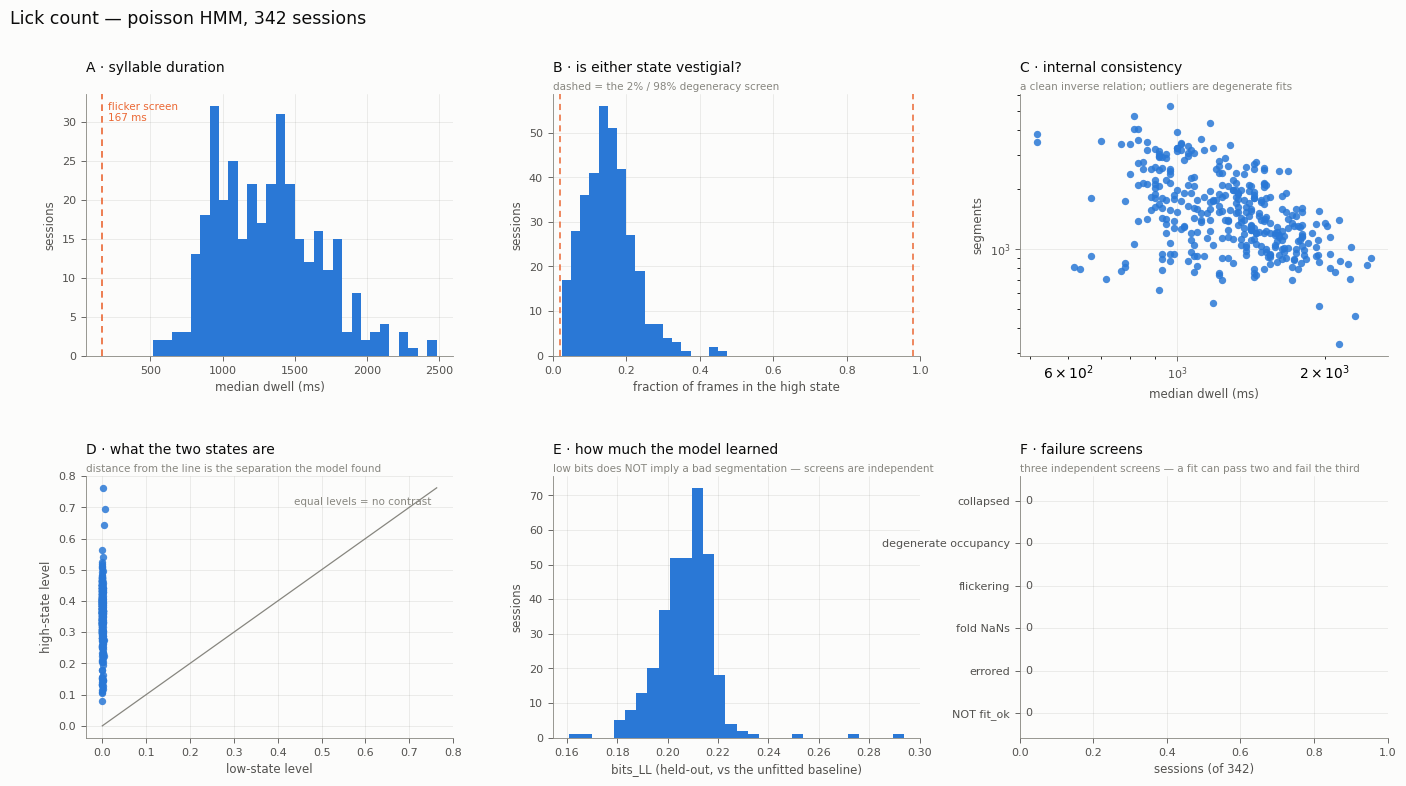

                  count           mean           std           min            25%            50%            75%            max
n_frames          342.0  275509.093567  58659.873022  1.027400e+05  240785.000000  267592.500000  314305.000000  438395.000000
n_segments        342.0    1673.160819    815.300895  3.330000e+02    1050.000000    1436.000000    2076.000000    5297.000000
median_dwell_ms   342.0    1315.350877    362.613527  5.166667e+02    1016.666667    1300.000000    1550.000000    2483.333333
occupancy_state1  342.0       0.152213      0.070236  2.600000e-02       0.102000       0.148100       0.190925       0.468100
level_low         342.0       0.000268      0.000637  4.745915e-07       0.000001       0.000008       0.000254       0.005819
level_high        342.0       0.360135      0.091994  7.966045e-02       0.318734       0.370899       0.413973       0.762351
raw_ll_per_frame  342.0      -0.142026      0.059693 -3.914262e-01      -0.176029      -0.139929      -0.098333

In [50]:
fig = P.plot_summary(df, var, fps=fps, target_dwell_ms=ANCHOR.get(var),
                    min_dwell_ms=min_dwell_ms)
plt.show()

print(df[[c for c in ['n_frames','n_segments','median_dwell_ms','occupancy_state1',
                      'level_low','level_high','raw_ll_per_frame','bits_LL']
          if c in df]].describe().T.to_string())

In [51]:
# per-mouse consistency: does a mouse segment the same way across its own sessions?
per_mouse = P.per_mouse_summary(df)
display(per_mouse)

multi = per_mouse[per_mouse.n >= 2]
if len(multi):
    print(f'{len(multi)} mice with >=2 sessions   |   '
          f'median within-mouse dwell spread {multi.dwell_spread.median():.0f} ms   |   '
          f'between-mouse SD of median dwell {multi.dwell_ms.std():.0f} ms')

,n,dwell_ms,dwell_spread,occupancy,bits,flagged
mouse,,,,,,
PL033,16,900.000000,183.333333,0.1264,0.202284,0
ibl_witten_29,9,1516.666667,316.666667,0.1674,0.208398,0
DY_009,9,1083.333333,283.333333,0.0612,0.213182,0
DY_020,8,1508.333333,283.333333,0.1232,0.220107,0
PL030,8,975.000000,250.000000,0.1260,0.212689,0
...,...,...,...,...,...,...
ZFM-02373,1,983.333333,0.000000,0.0807,0.210905,0
ZM_2245,1,1516.666667,0.000000,0.1594,0.198697,0
ibl_witten_25,1,1150.000000,0.000000,0.3011,0.275631,0


81 mice with >=2 sessions   |   median within-mouse dwell spread 233 ms   |   between-mouse SD of median dwell 330 ms


## One session

Give an **eid** — the 8-character prefix is enough, the mouse is looked up for you — and
optionally `start_s` to move the window elsewhere in the session. Rerun with a different
`start_s` to walk through the recording.

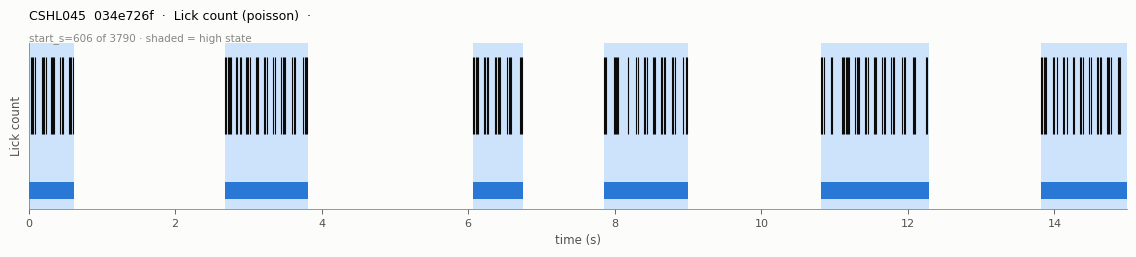

poisson HMM · Lick count · 034e726f-b35f-41e0-8d6c-a22cc32391fb
  session length   63.2 min
  fold used        4   (per-fold held-out LL: [-0.3045 -0.2726 -0.2036 -0.0277 -0.015 ])
  emission levels  [0.     0.4112]
  dwell            1033 ms median, 1983 ms mean over 1,911 segments
  occupancy        0.157 in the high state


In [52]:
eid = df.iloc[0]['eid']
start_s = None      # None = auto-pick an informative window; or e.g. 1200 for 20 min in
win_s = 15

fig, d = P.plot_session(save_path, data_path, var, eid=eid,
                        num_train_batches=num_train_batches, fps=fps,
                        win_s=win_s, start_s=start_s)
plt.show()

a = d['assessment']
print(f"{d['config']['model']} HMM · {var} · {eid}")
print(f"  session length   {len(d['most_likely_states']) / fps / 60:.1f} min")
print(f"  fold used        {d['use_fold']}   (per-fold held-out LL: "
      f"{np.round(np.asarray(d['all_lls']), 4)})")
print(f"  emission levels  {np.round(d['emission_levels'].ravel(), 4)}")
print(f"  dwell            {a['median_dwell_ms']:.0f} ms median, "
      f"{a['mean_dwell_frames'] * 1000 / fps:.0f} ms mean over {a['n_segments']:,} segments")
print(f"  occupancy        {a['occupancy_state1']:.3f} in the high state")

## Several sessions in a row

Set `only_flagged = True` for the ones that failed a screen — that is the list worth going
through by eye.

showing 183 of 183


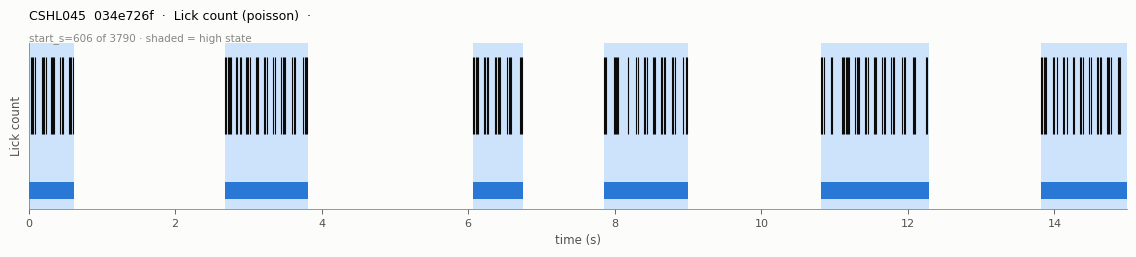

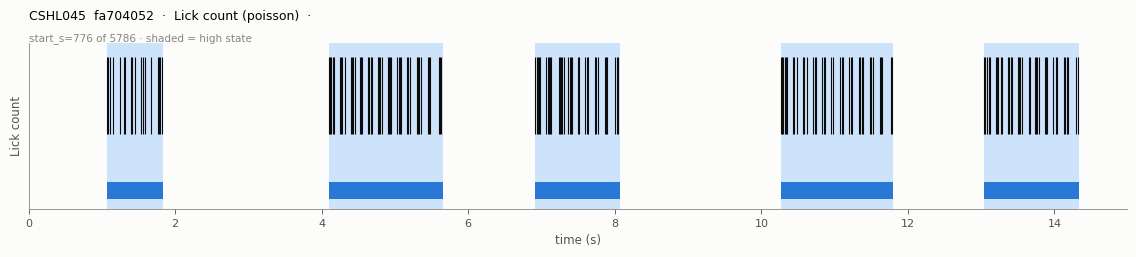

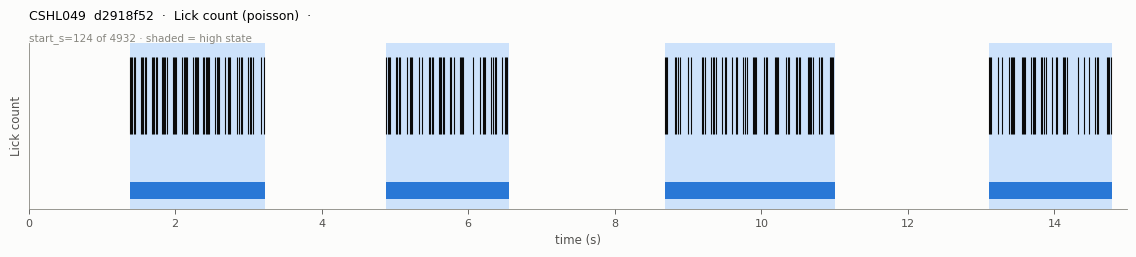

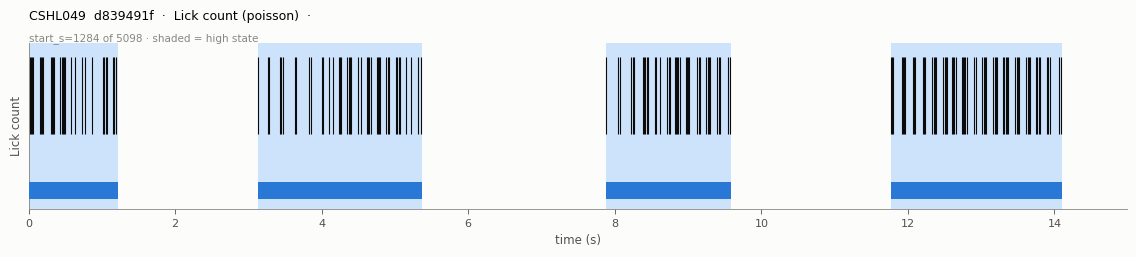

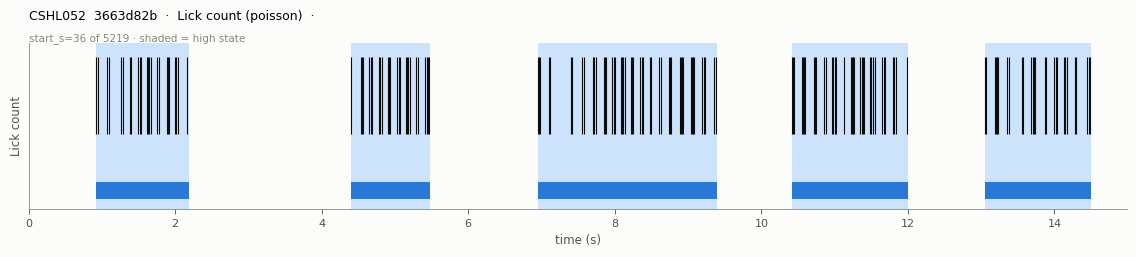

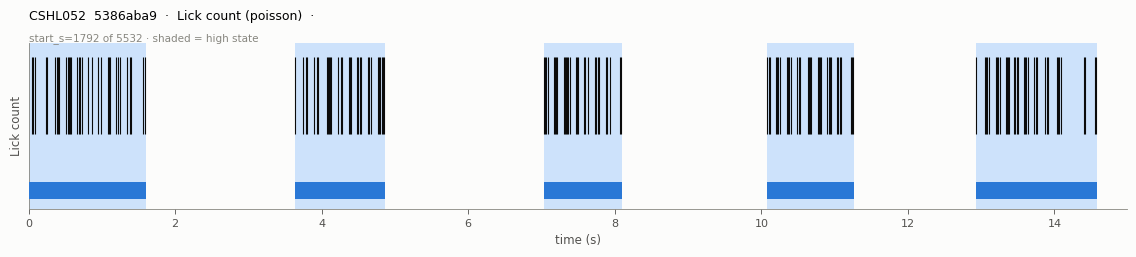

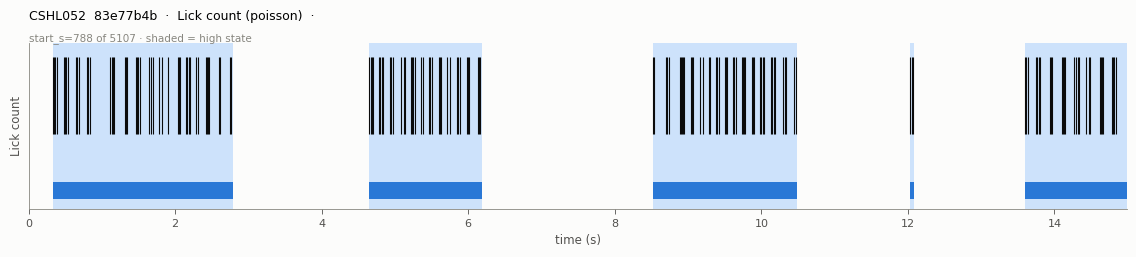

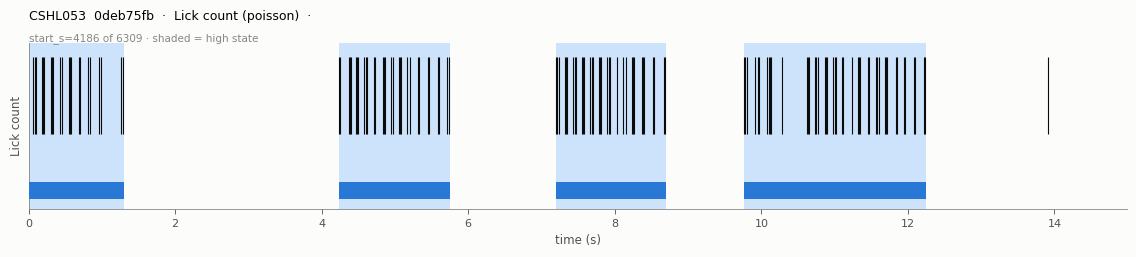

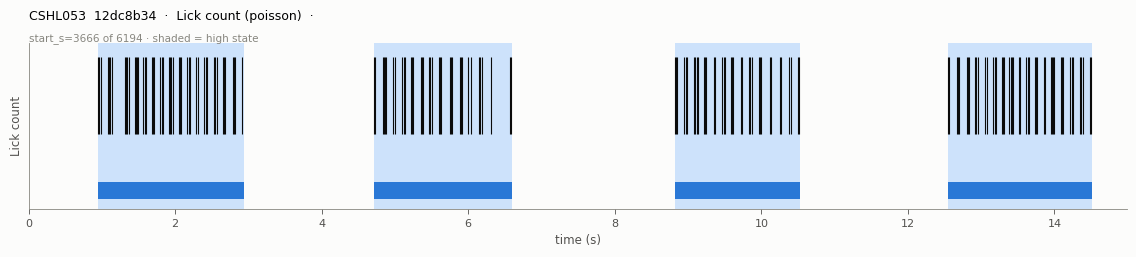

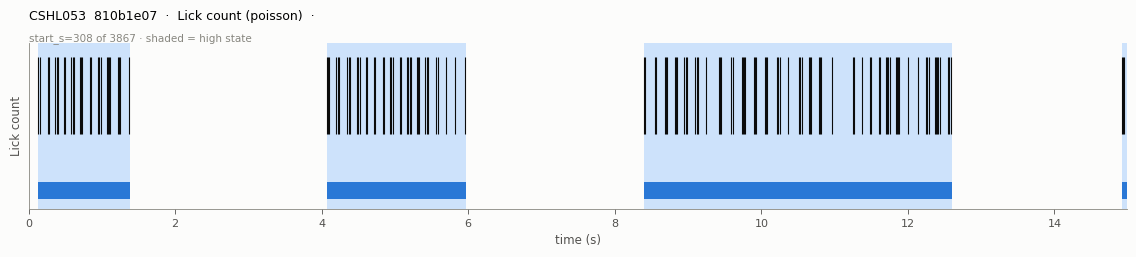

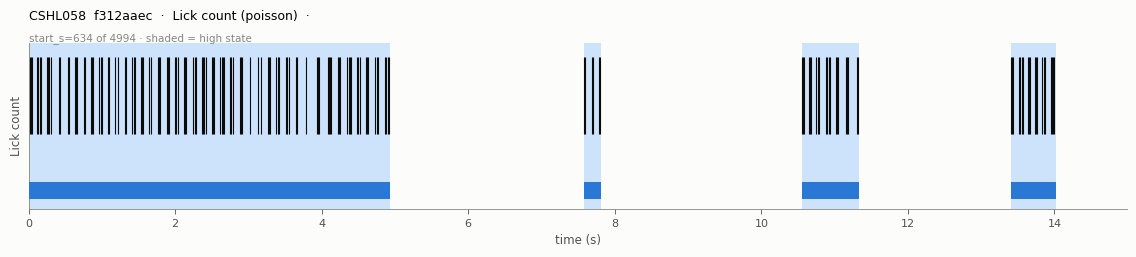

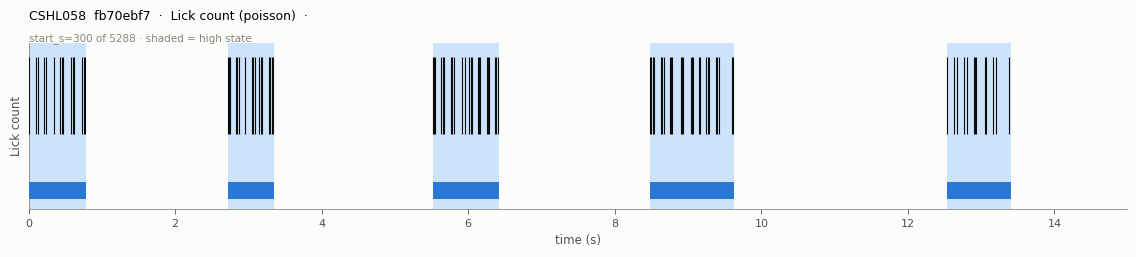

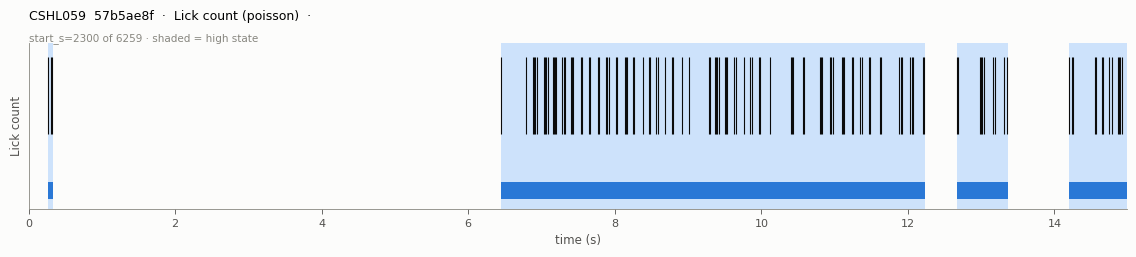

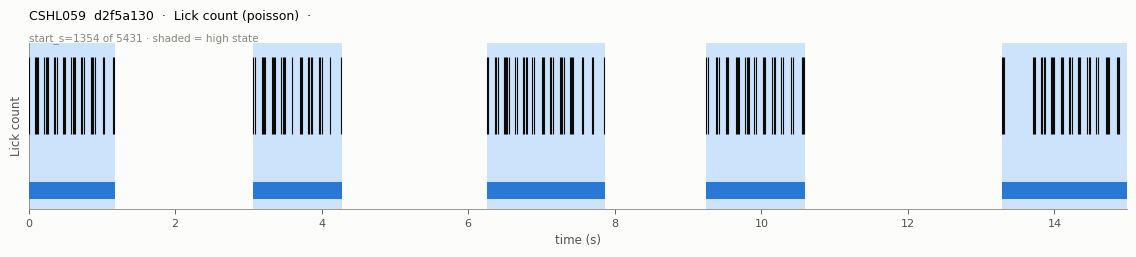

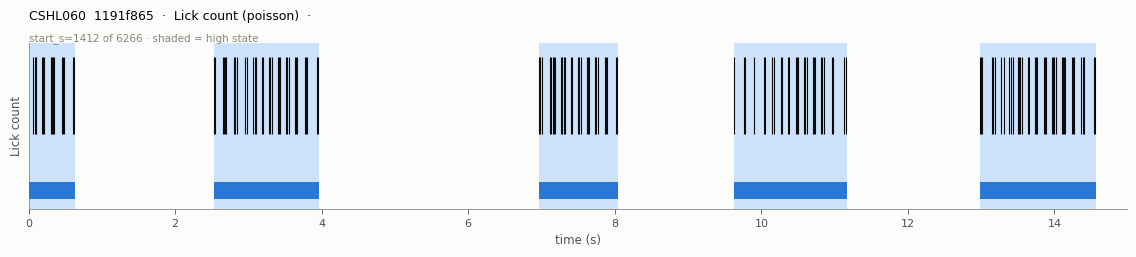

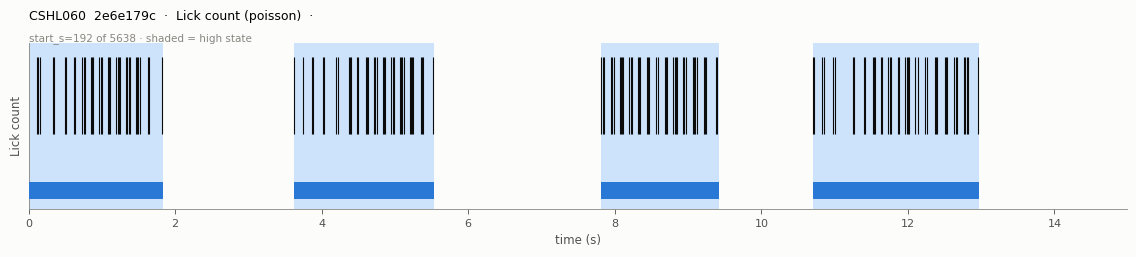

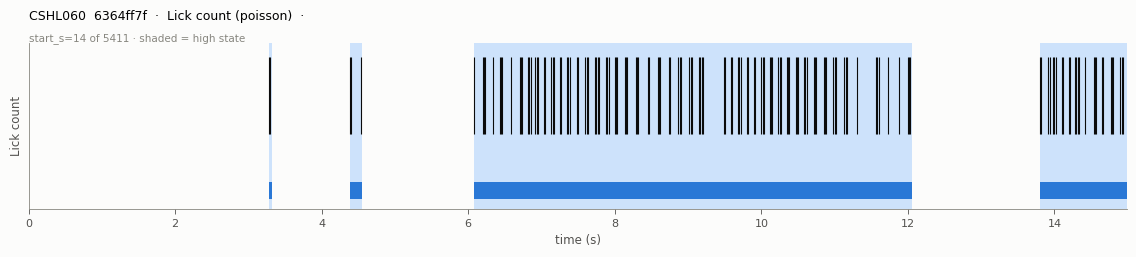

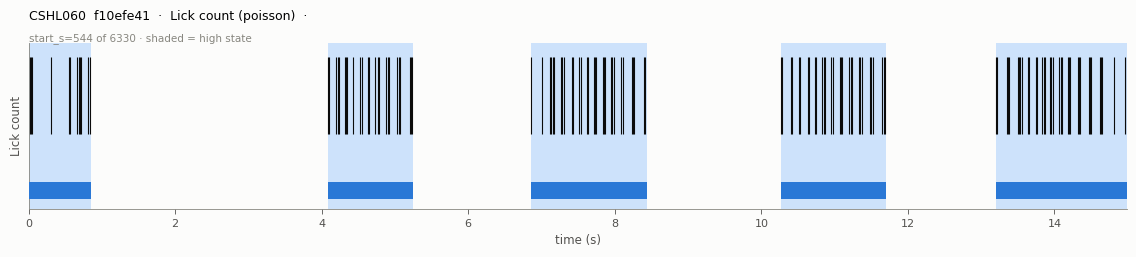

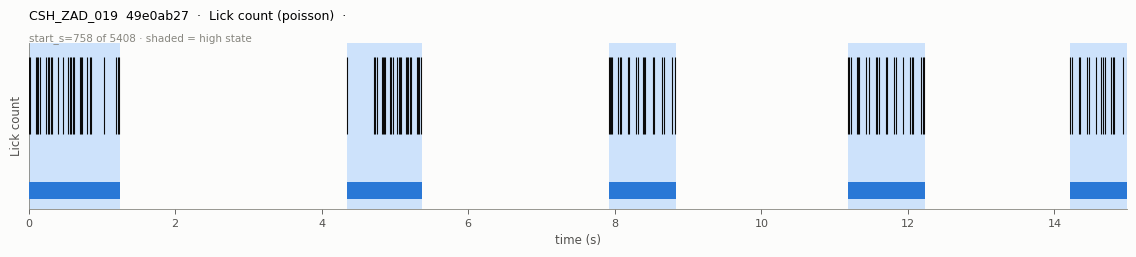

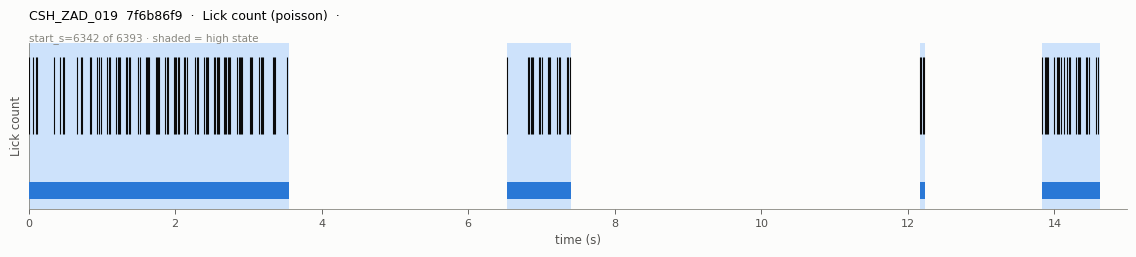

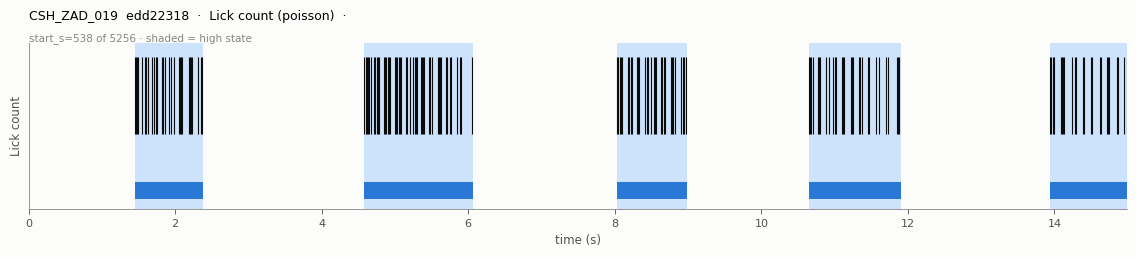

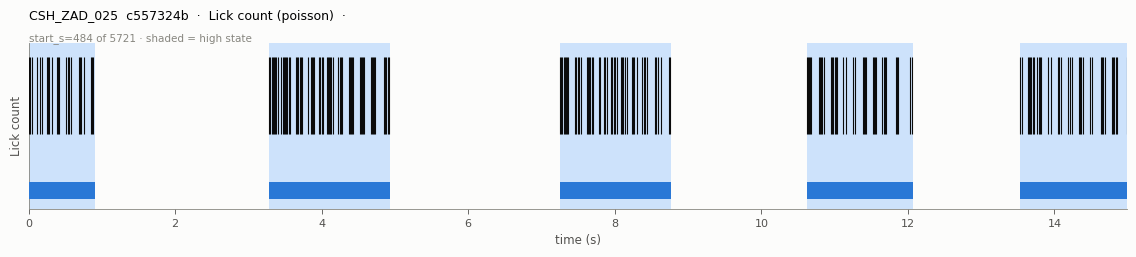

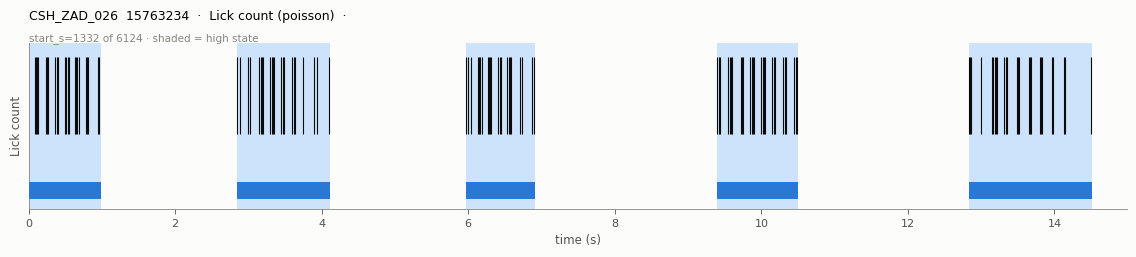

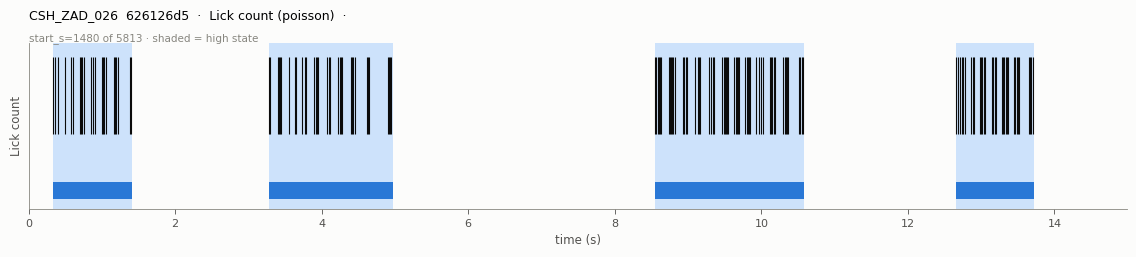

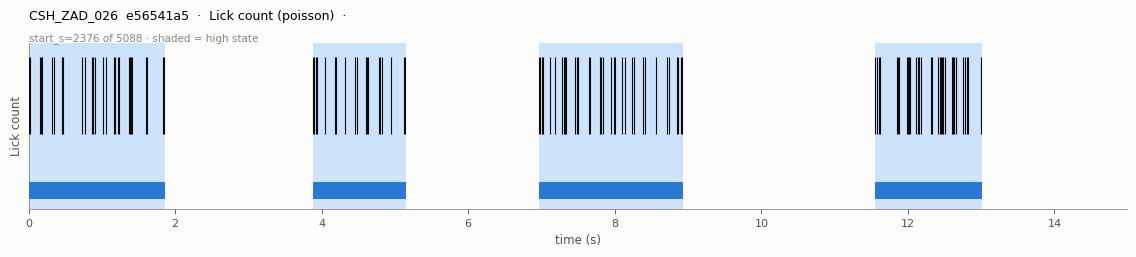

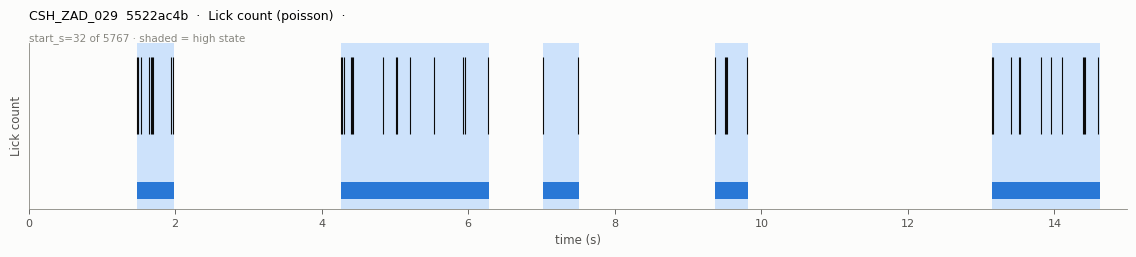

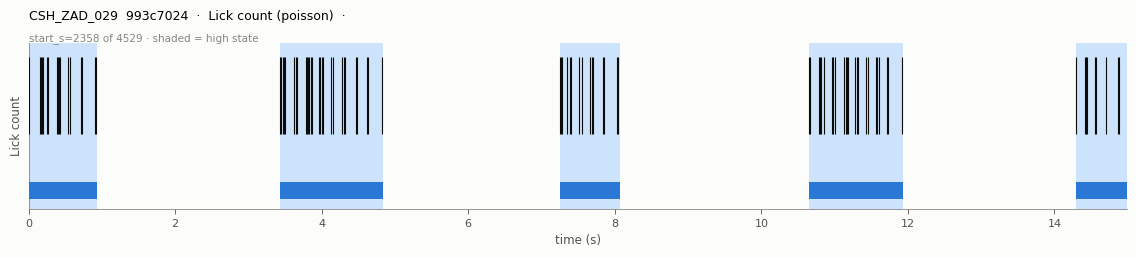

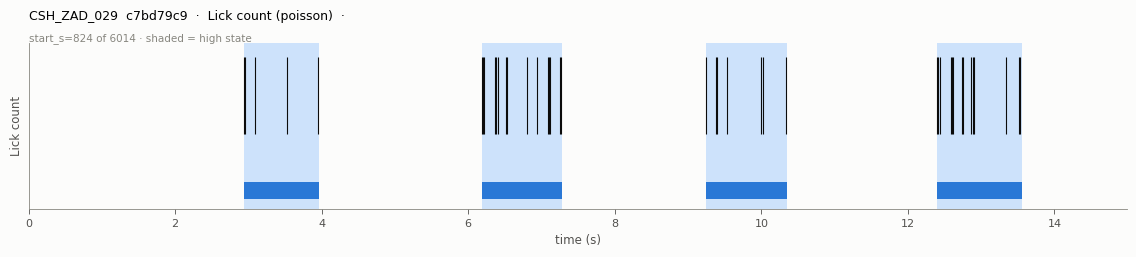

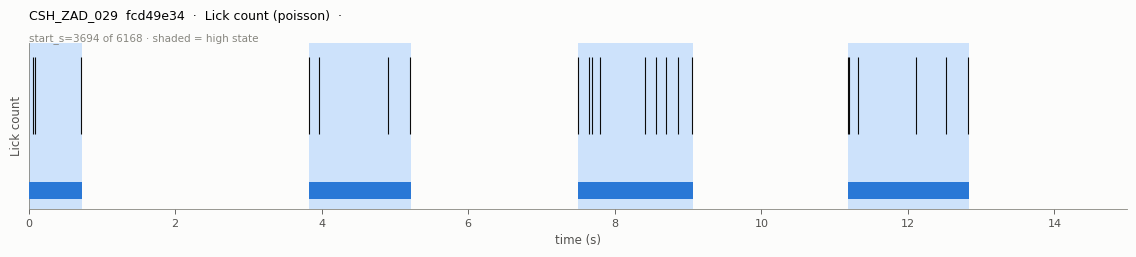

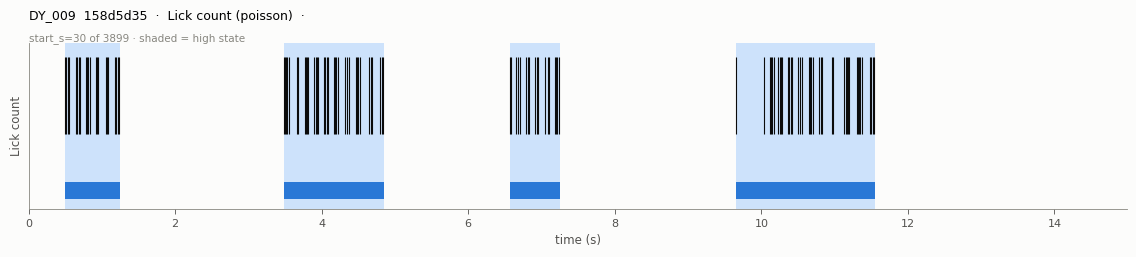

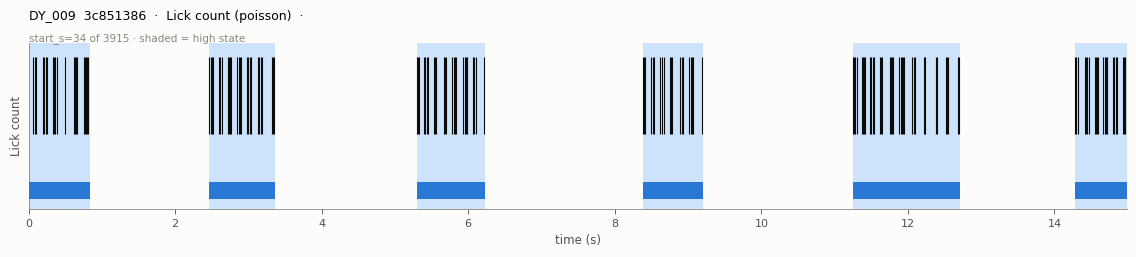

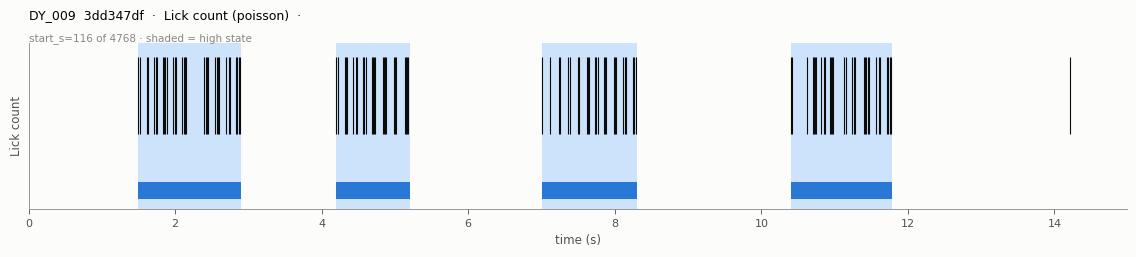

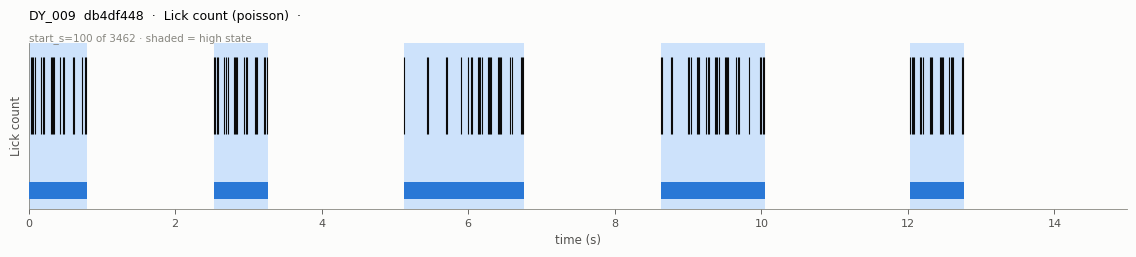

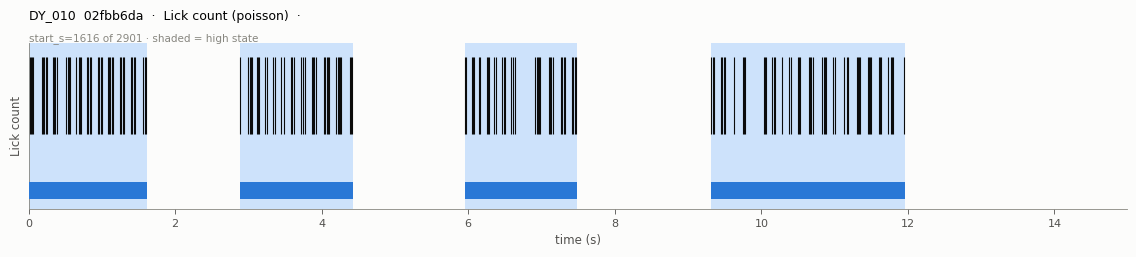

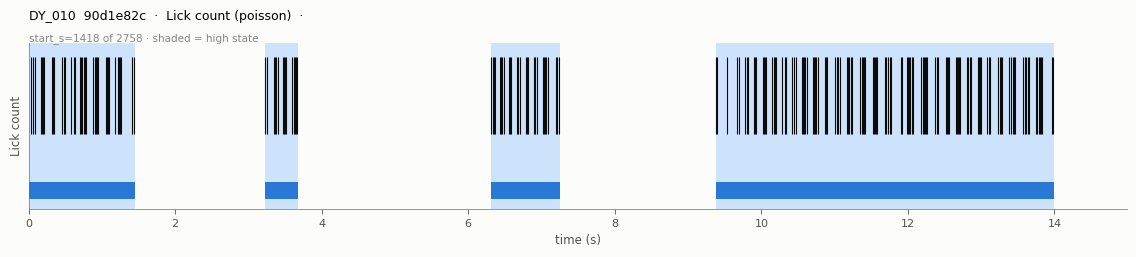

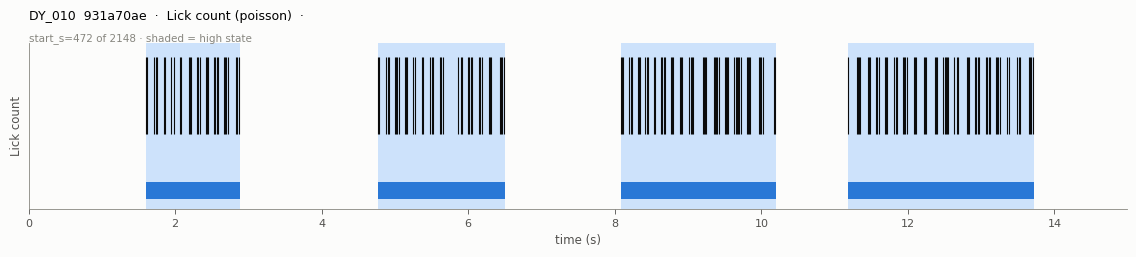

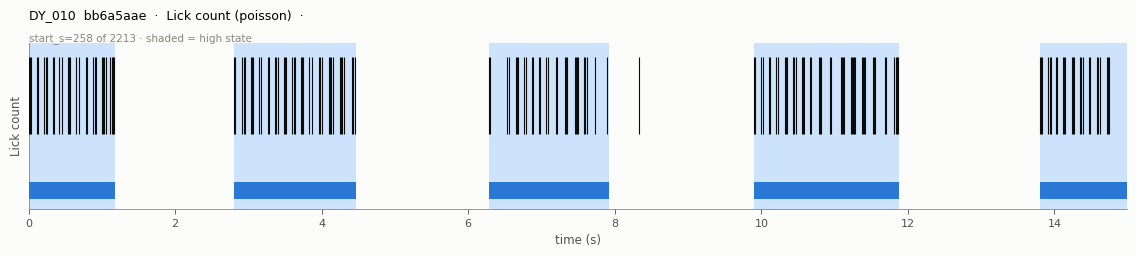

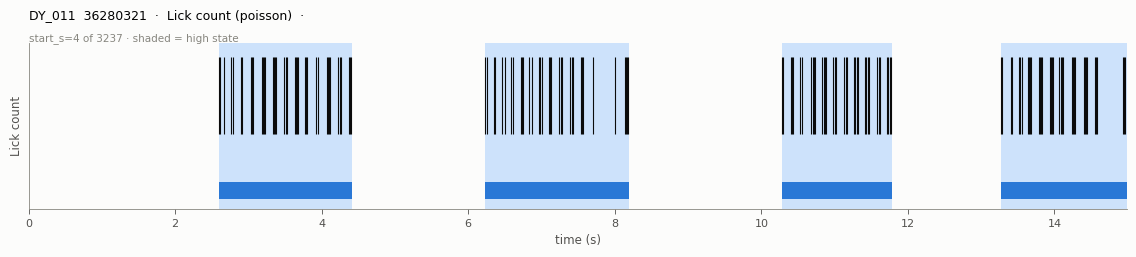

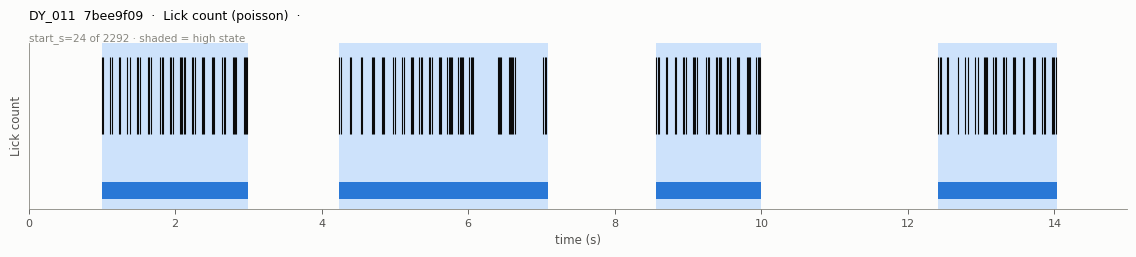

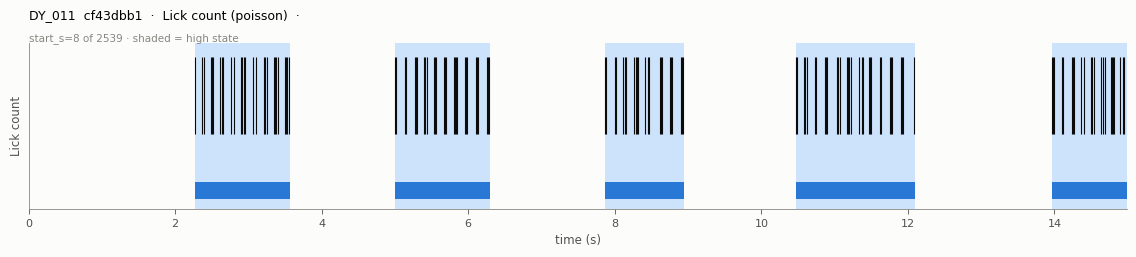

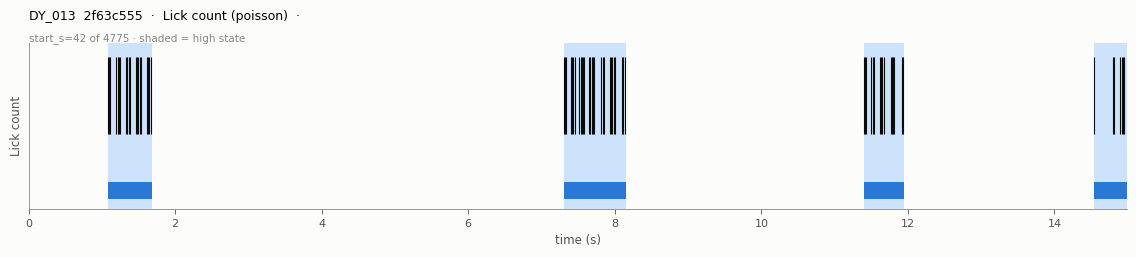

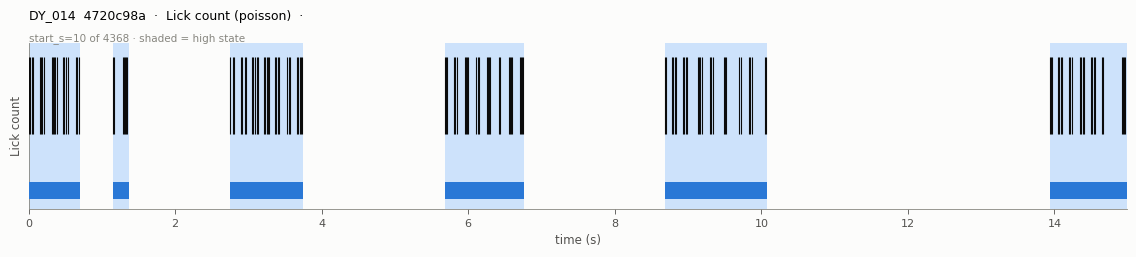

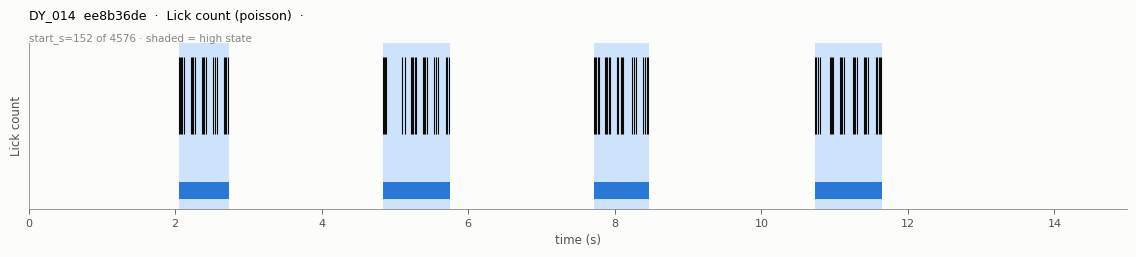

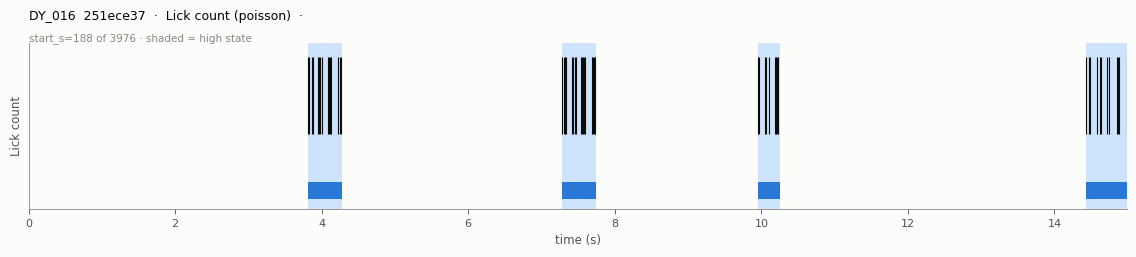

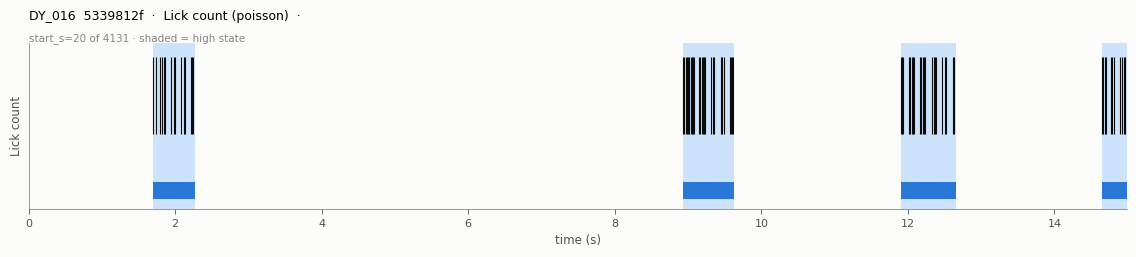

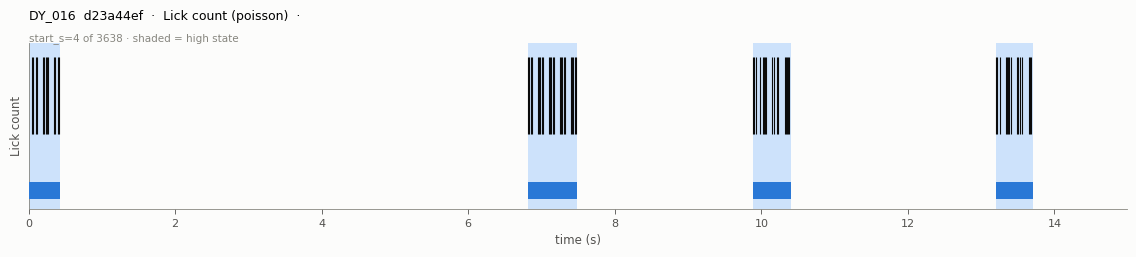

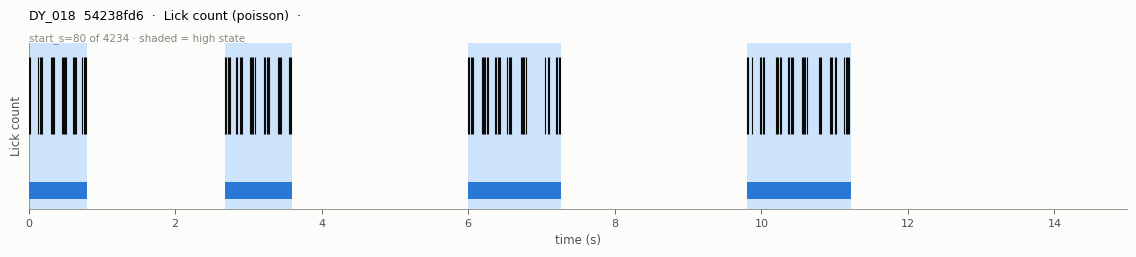

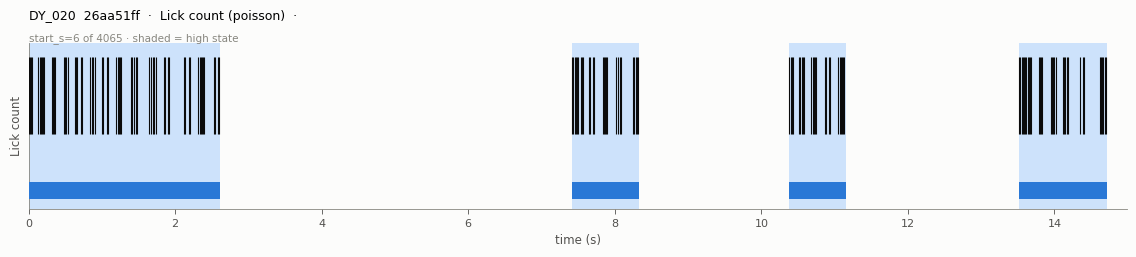

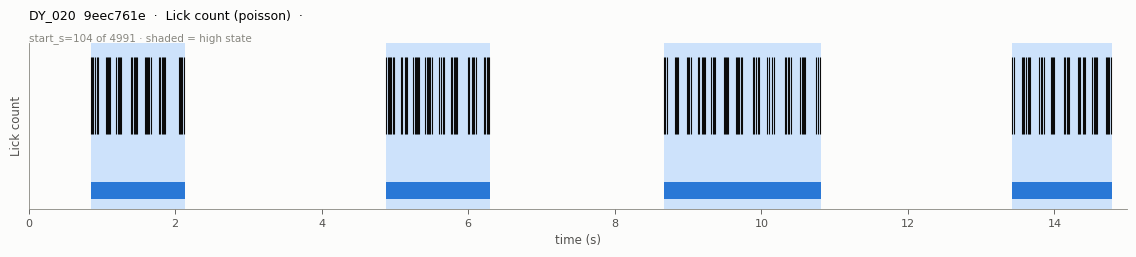

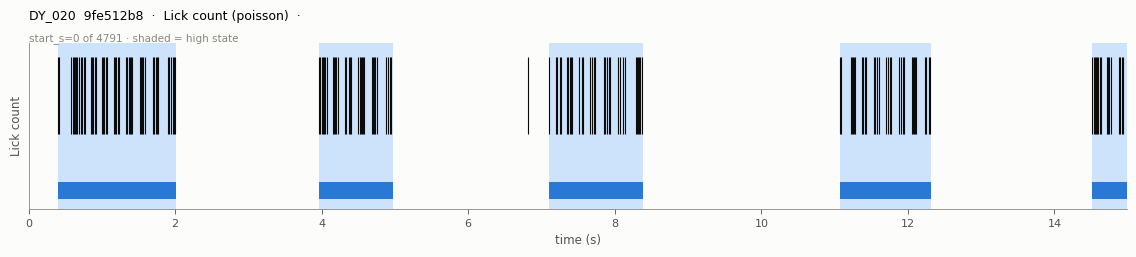

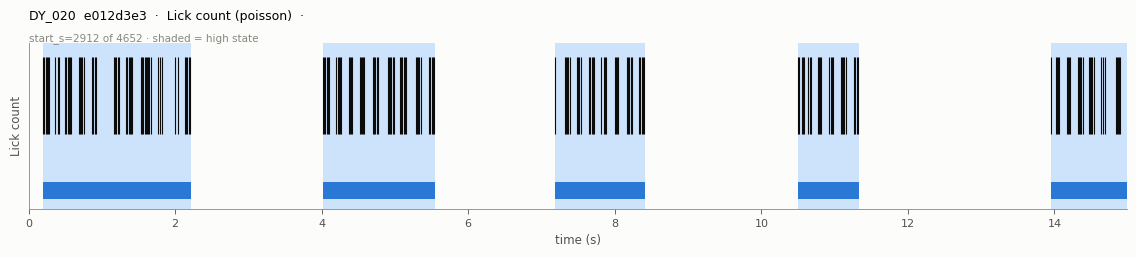

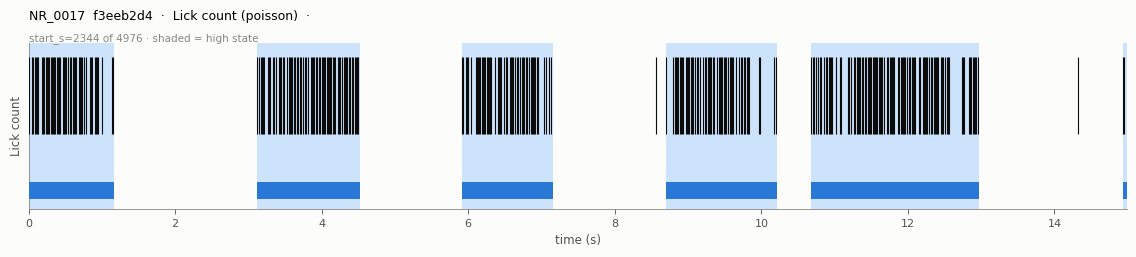

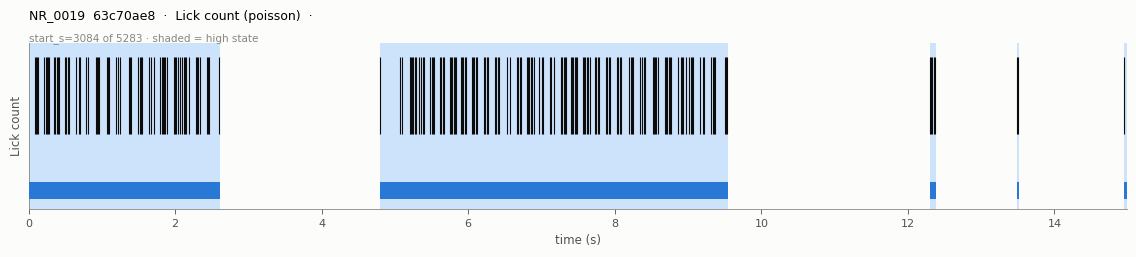

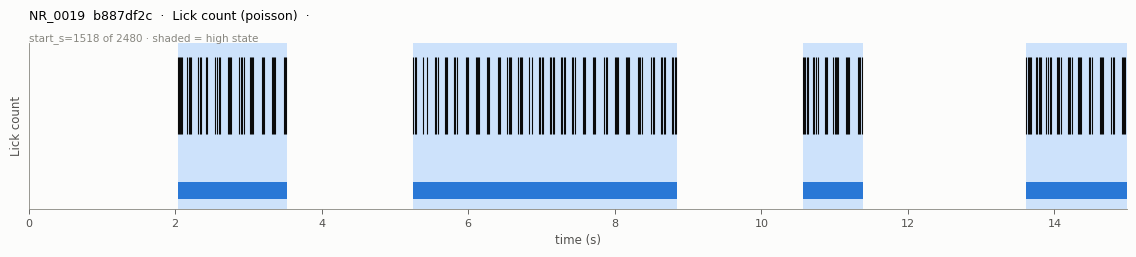

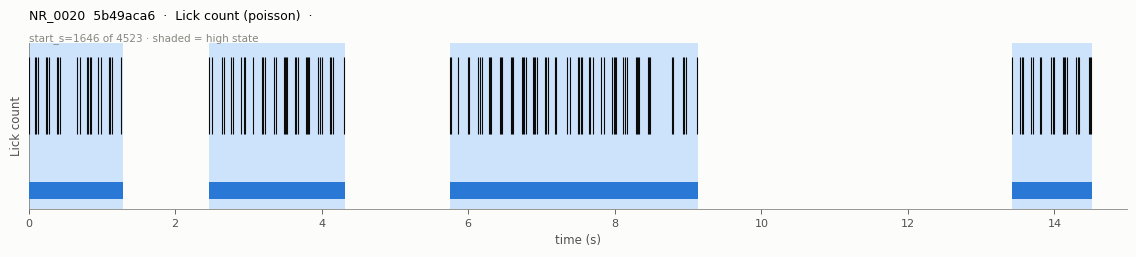

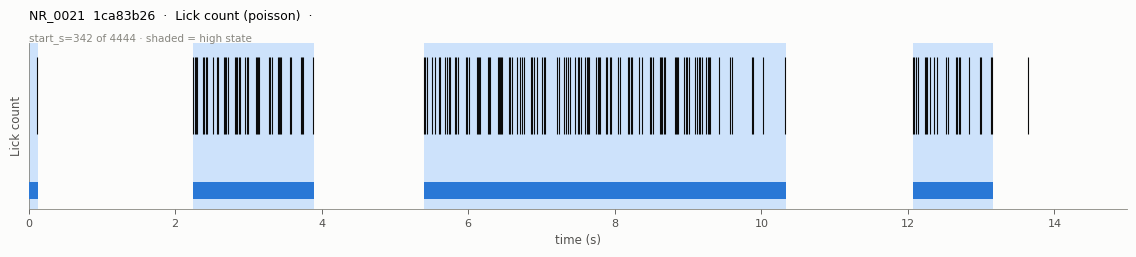

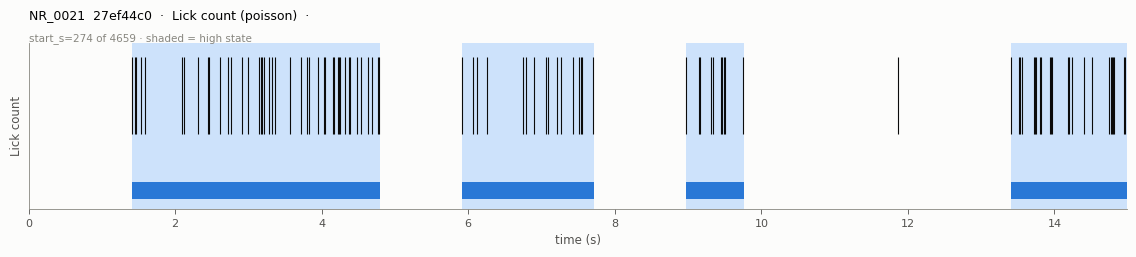

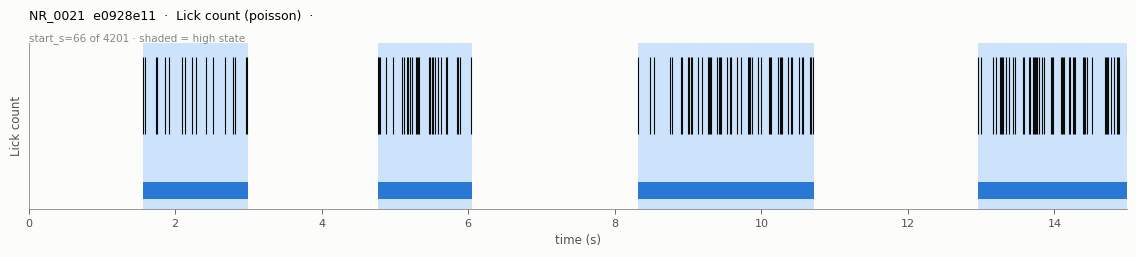

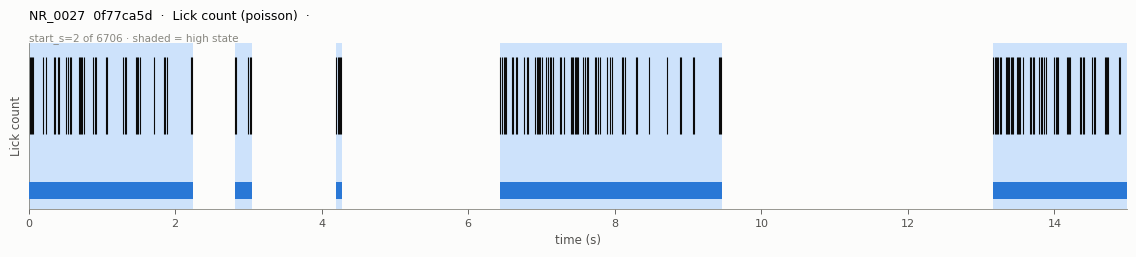

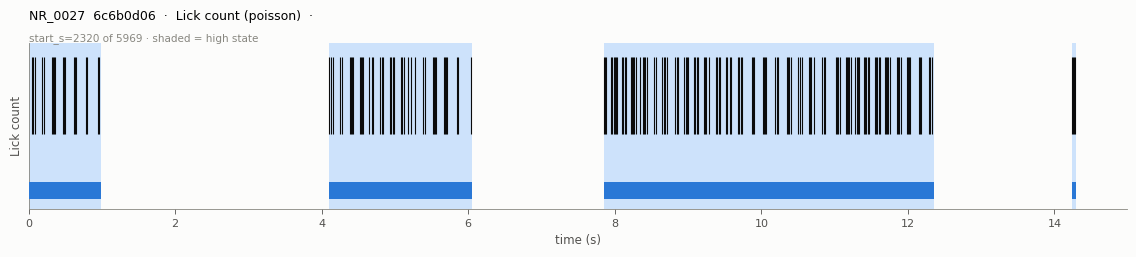

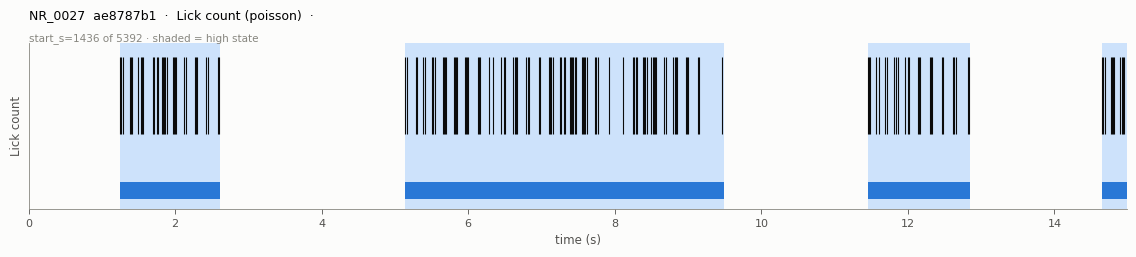

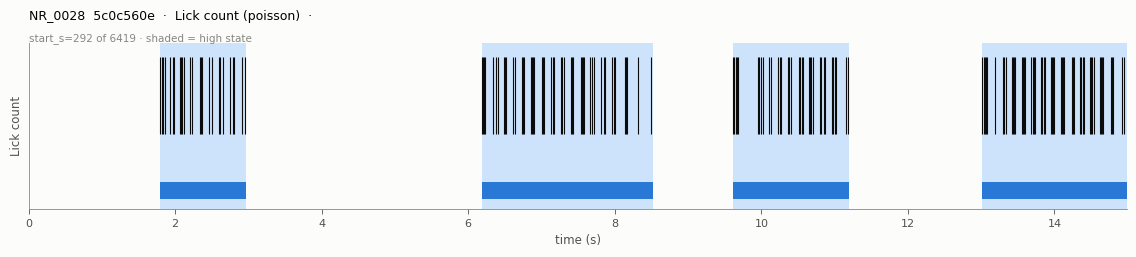

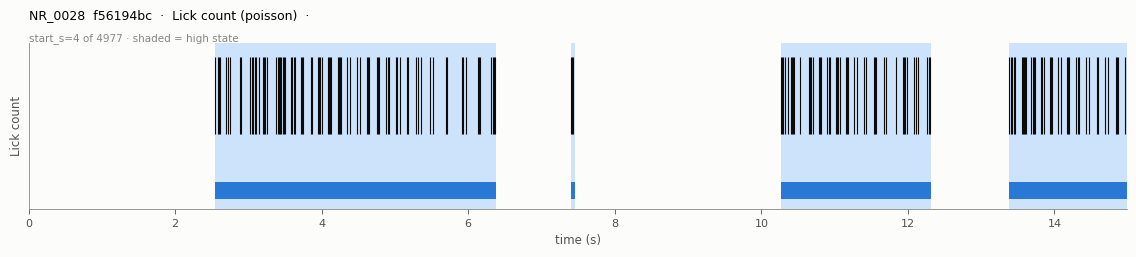

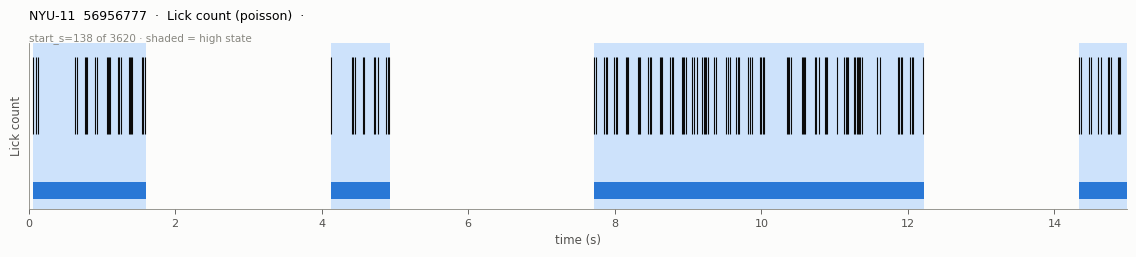

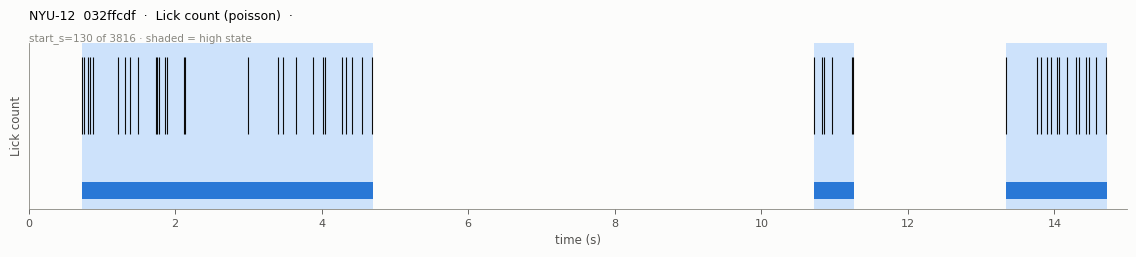

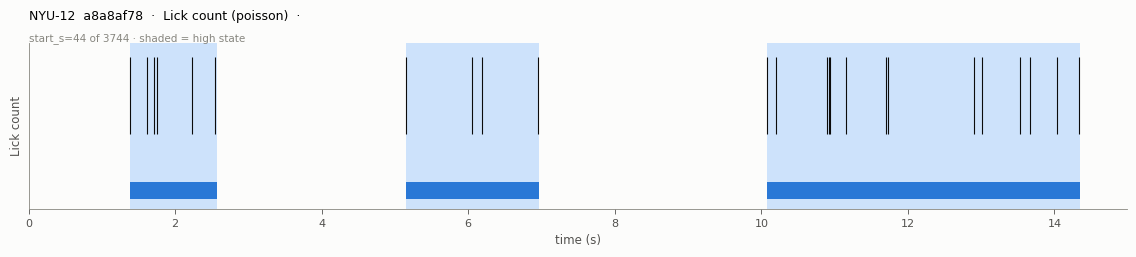

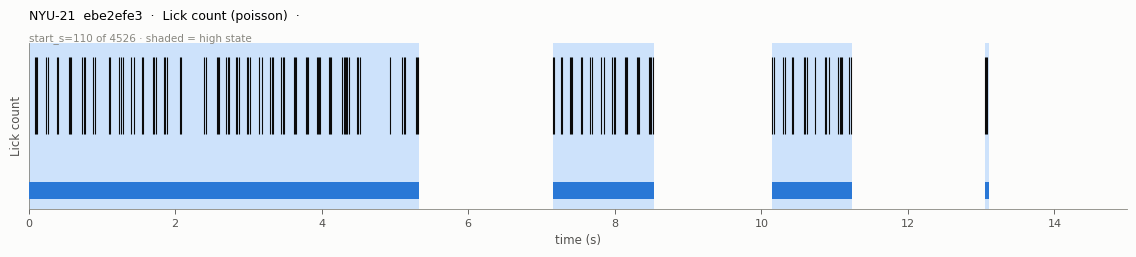

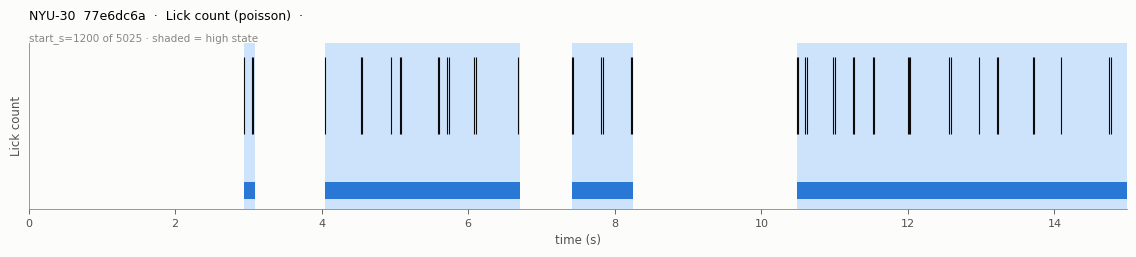

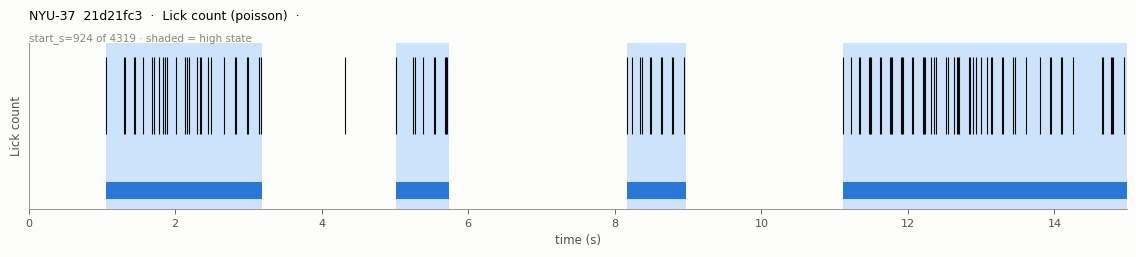

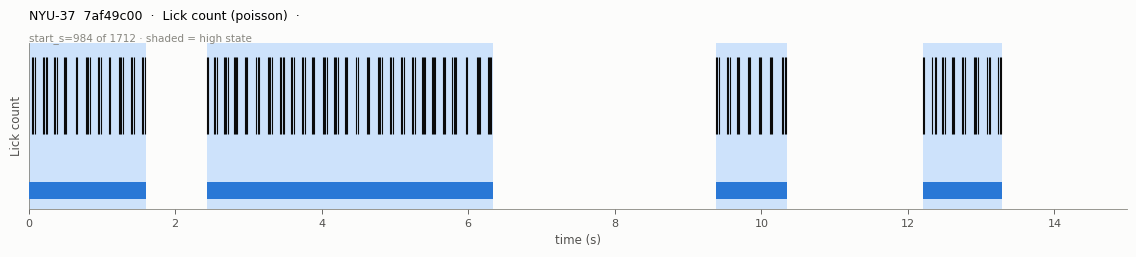

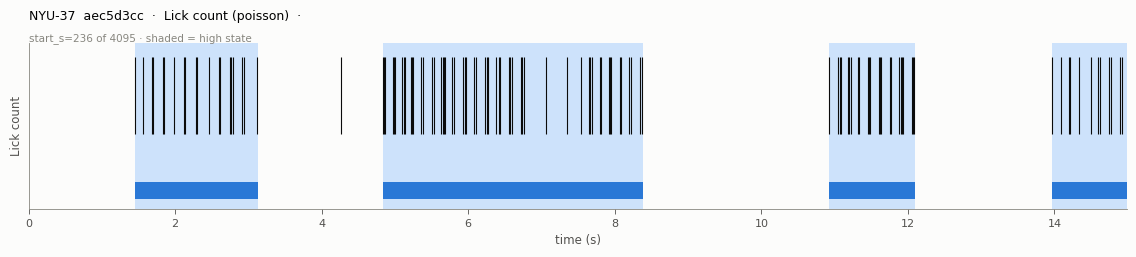

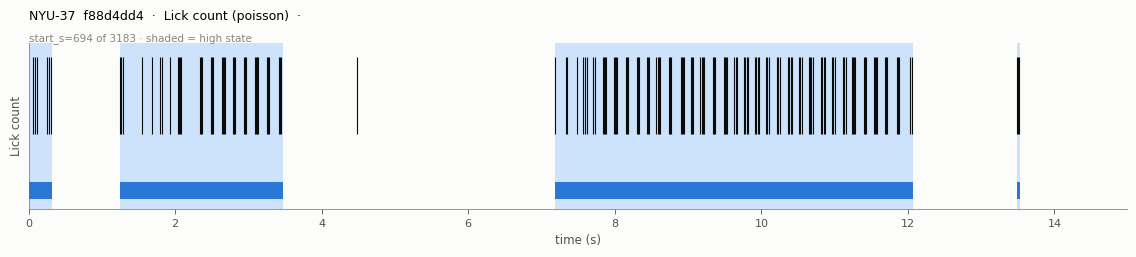

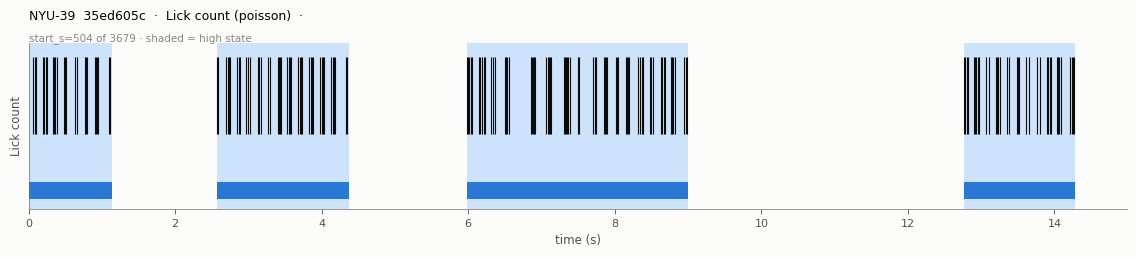

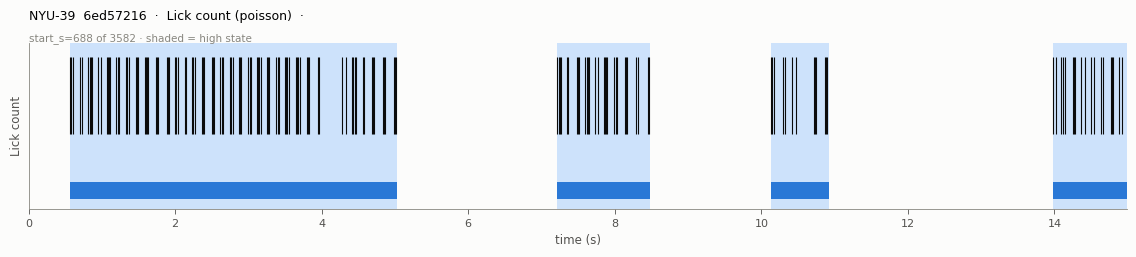

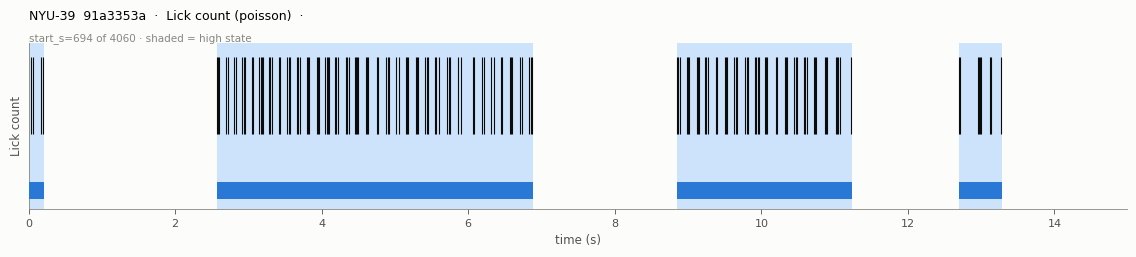

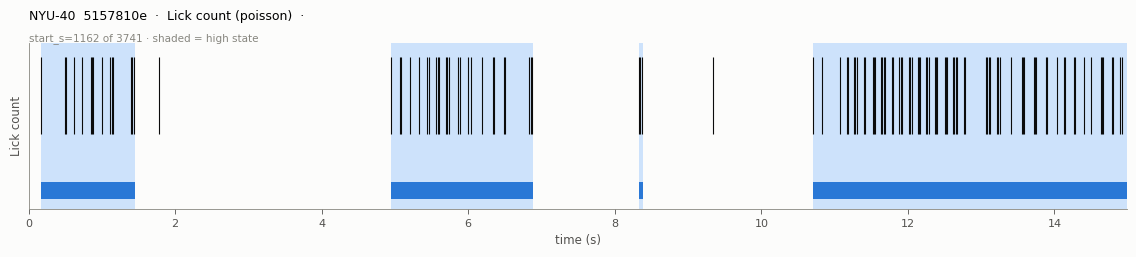

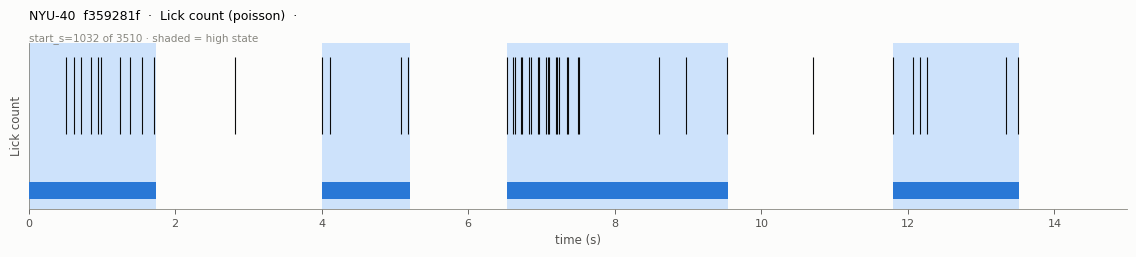

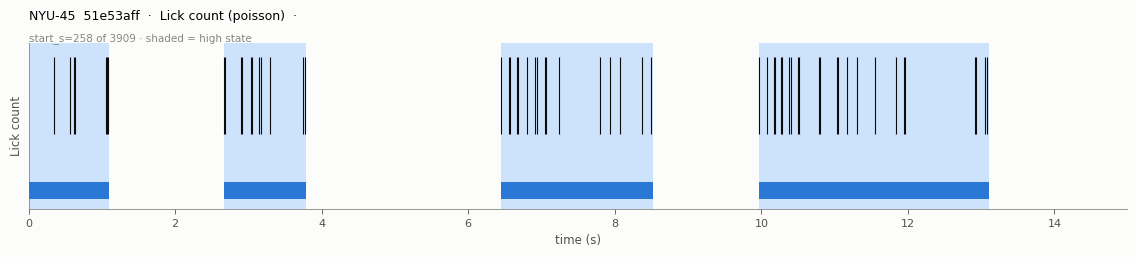

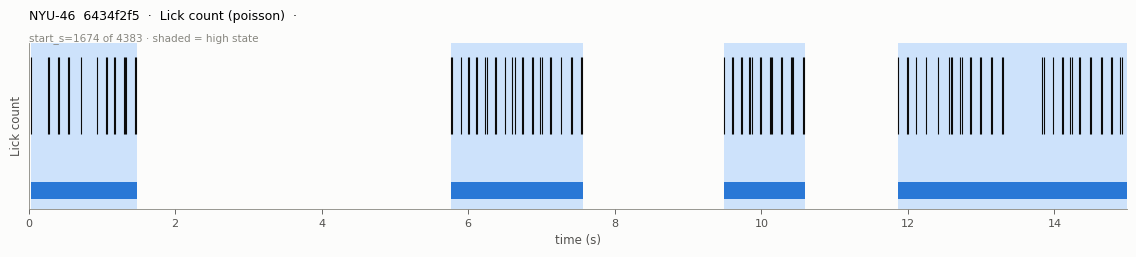

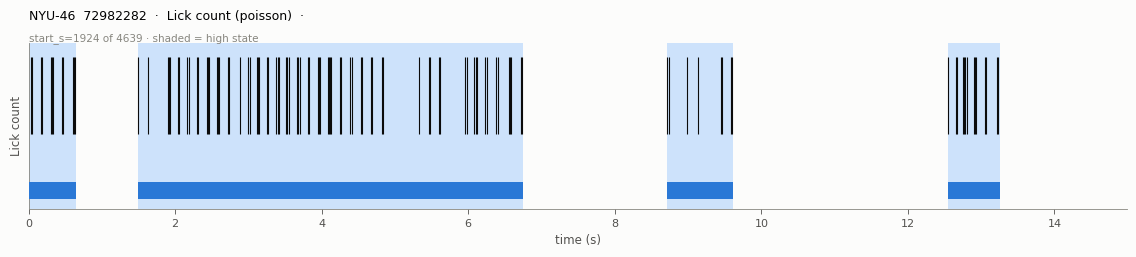

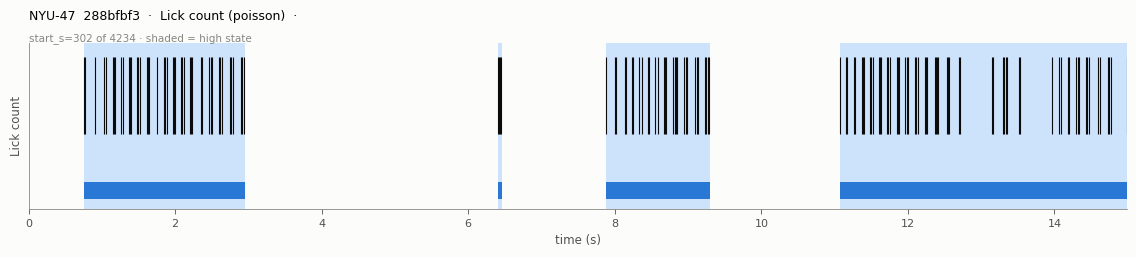

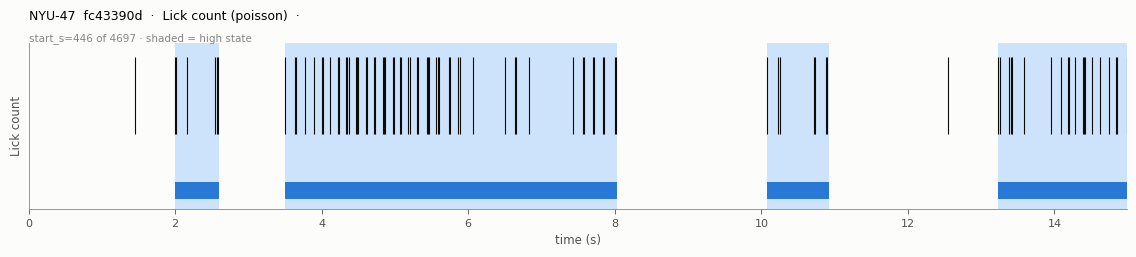

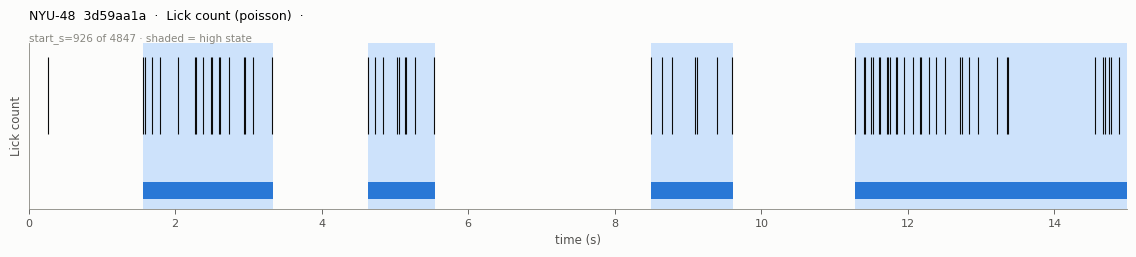

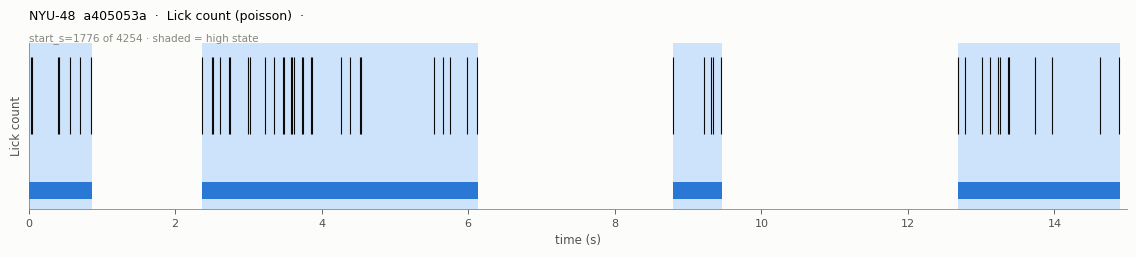

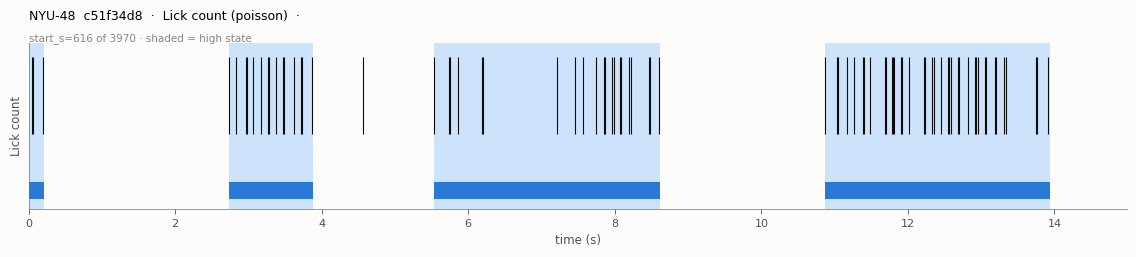

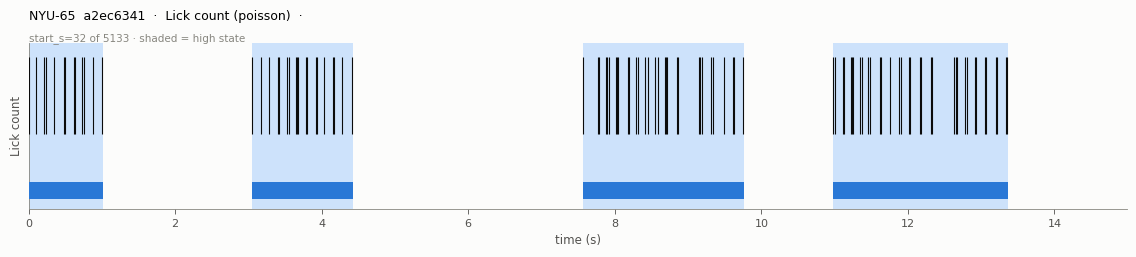

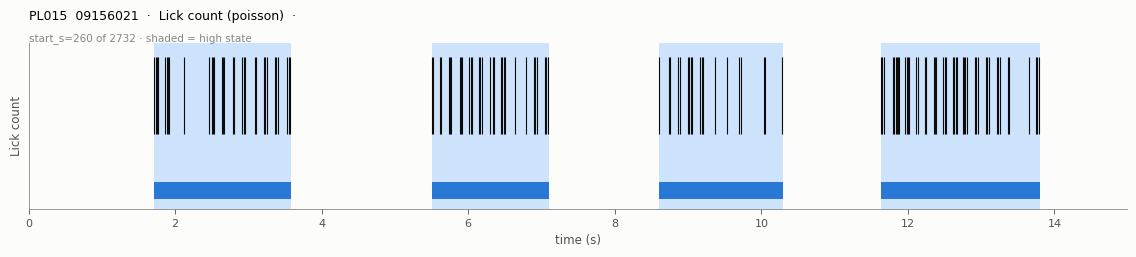

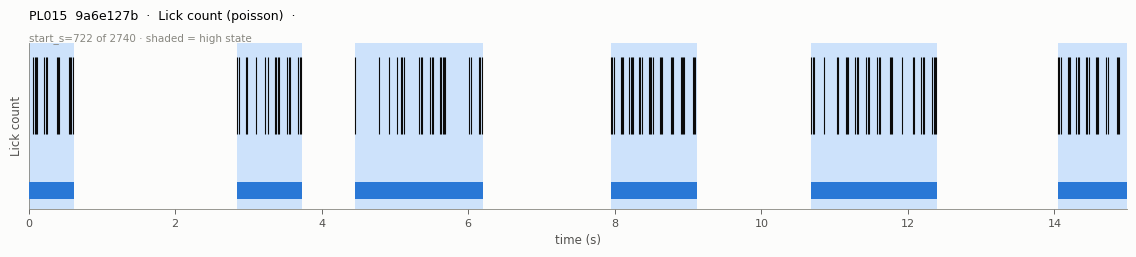

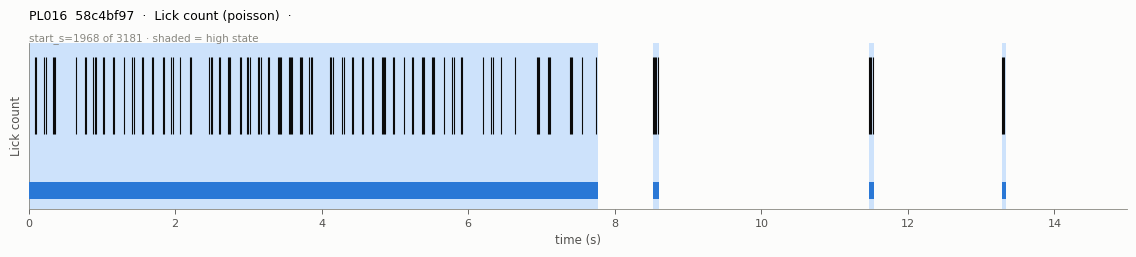

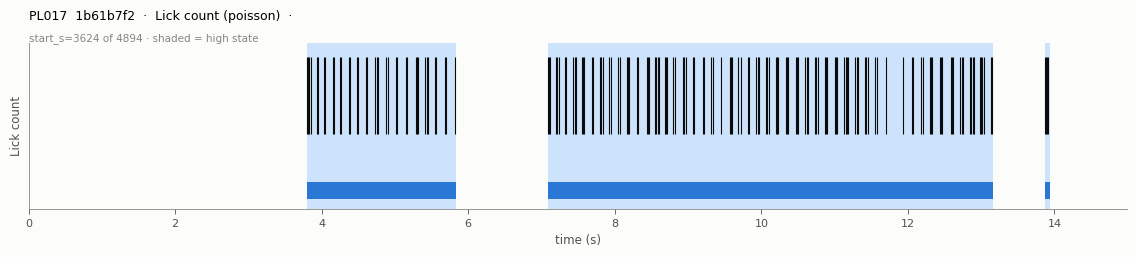

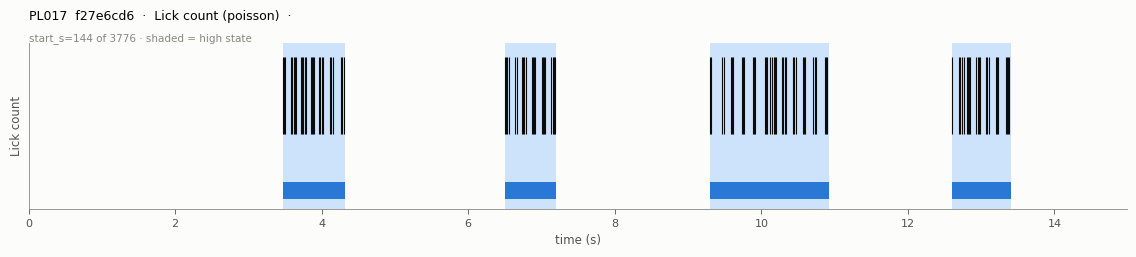

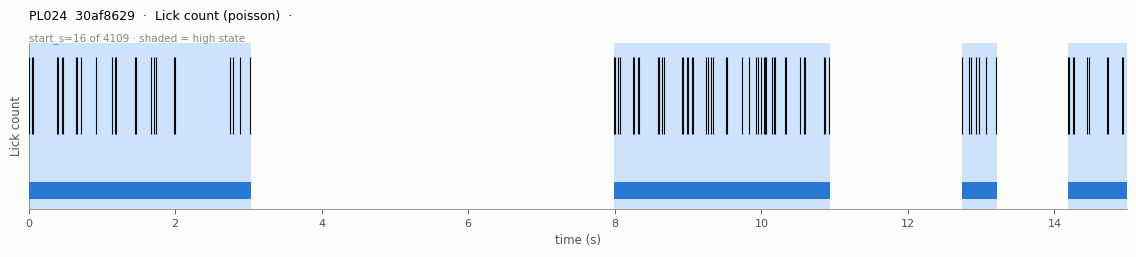

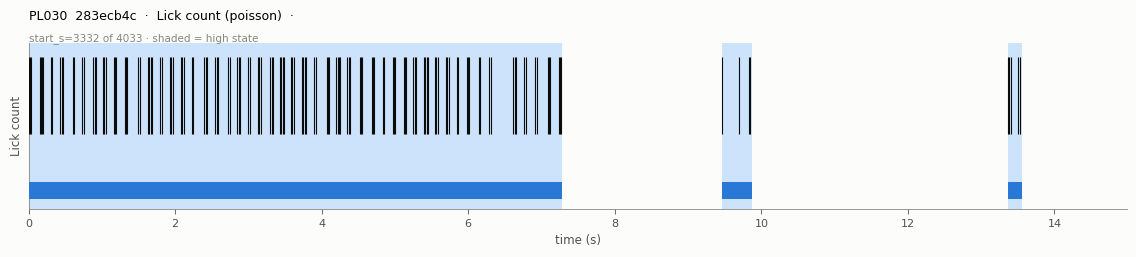

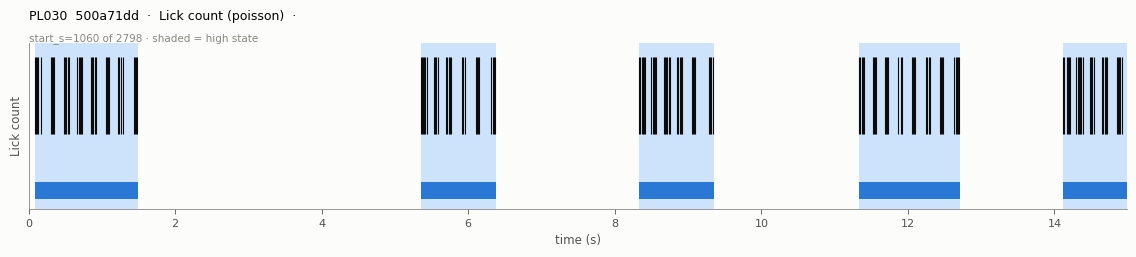

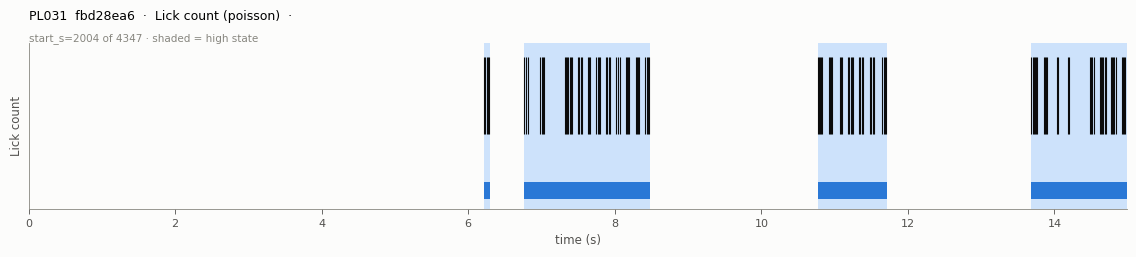

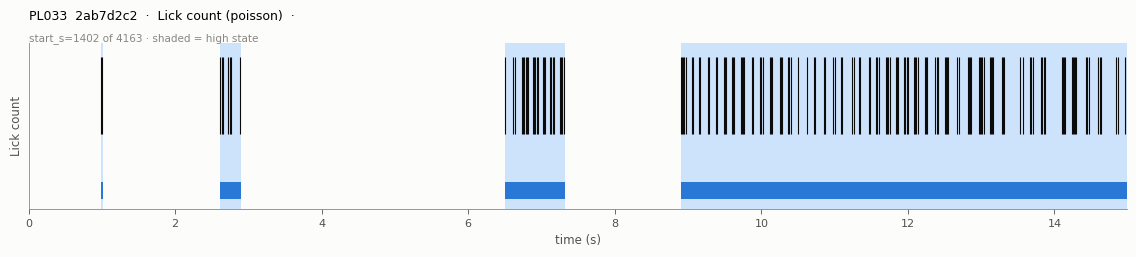

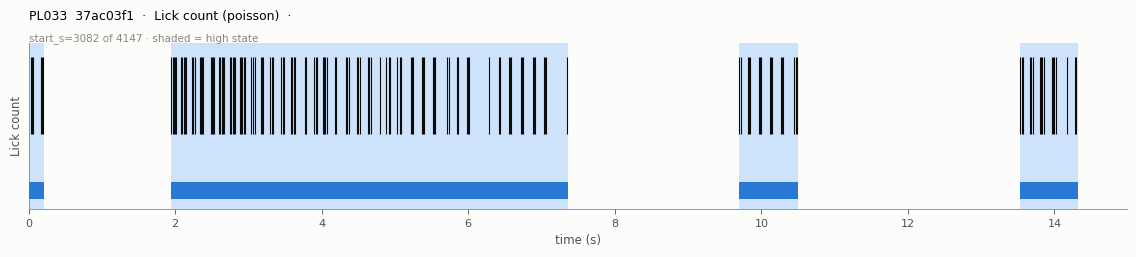

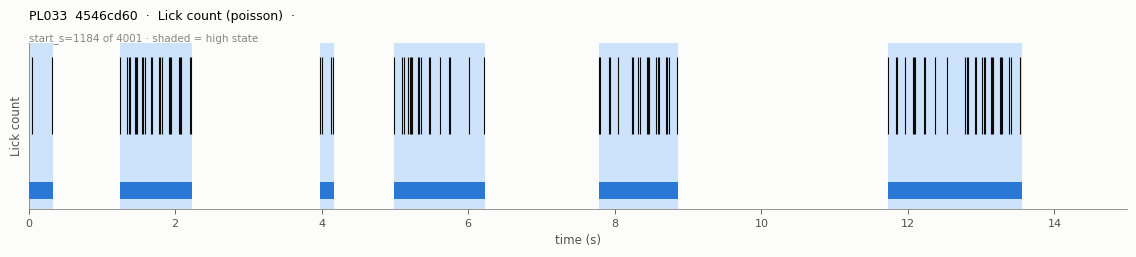

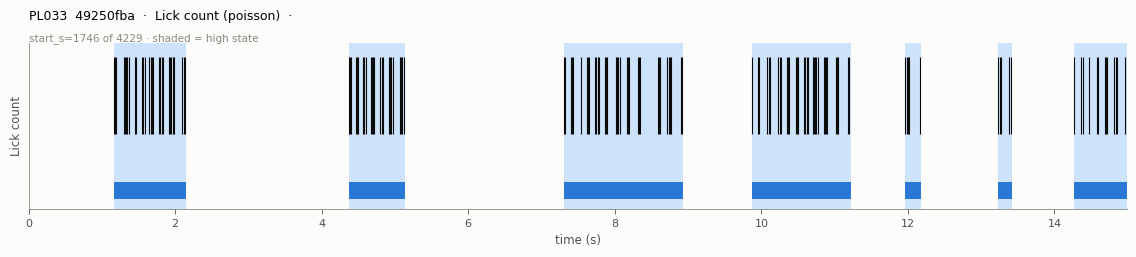

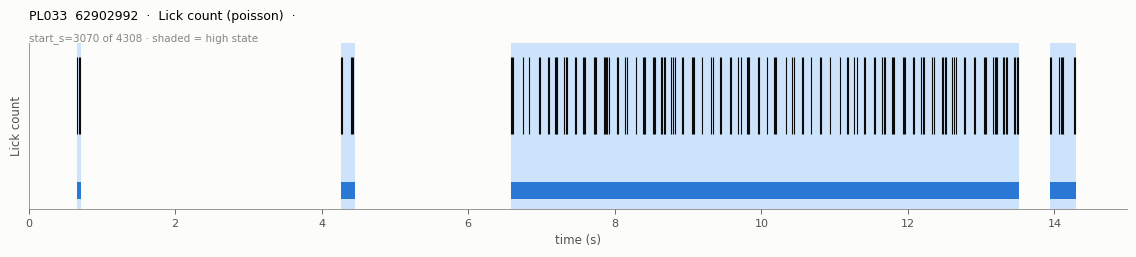

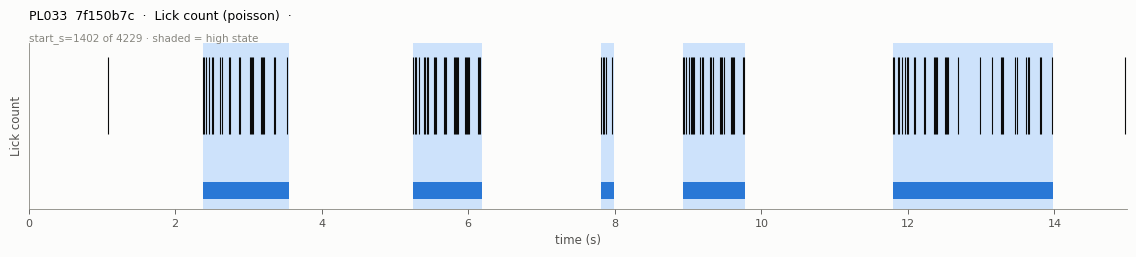

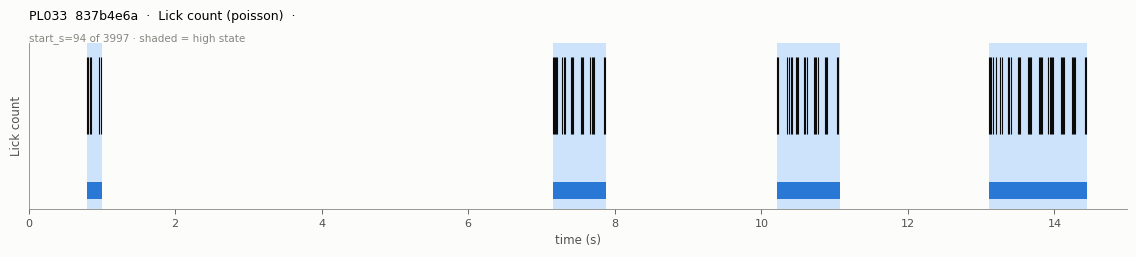

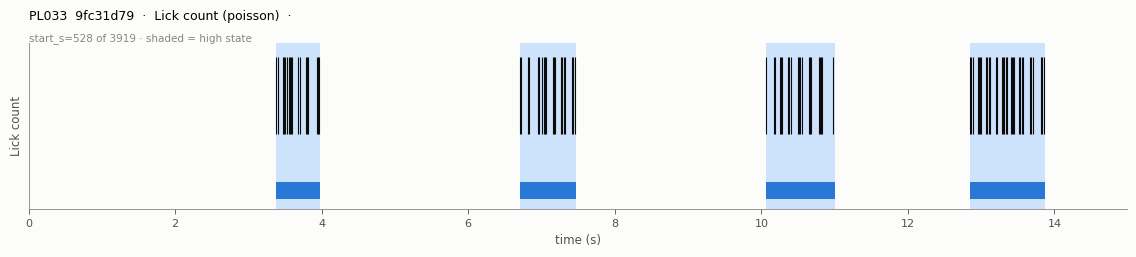

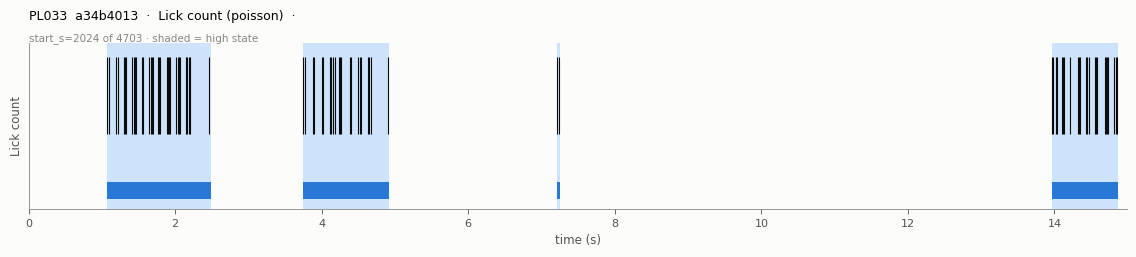

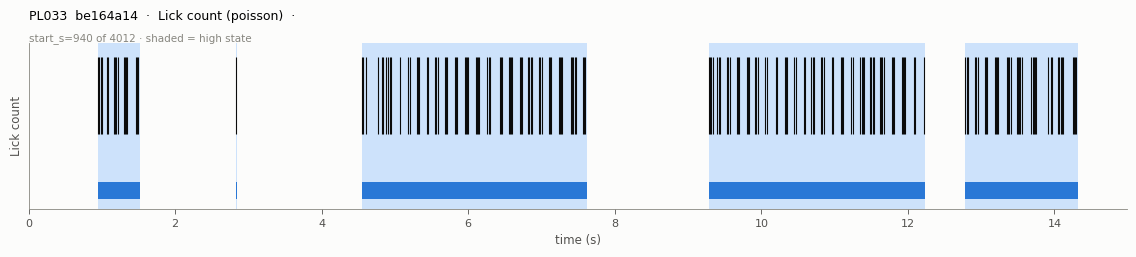

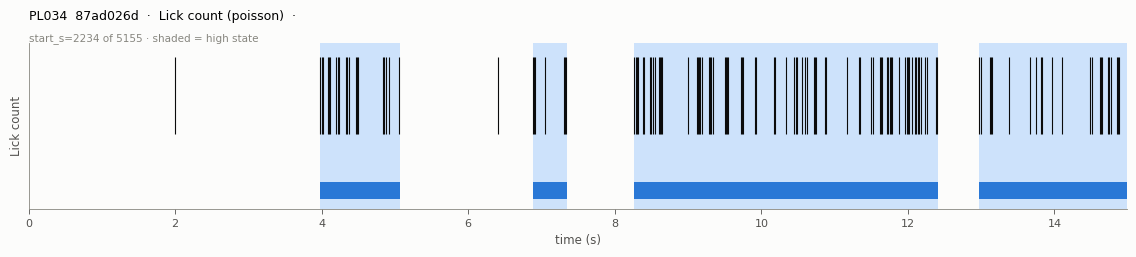

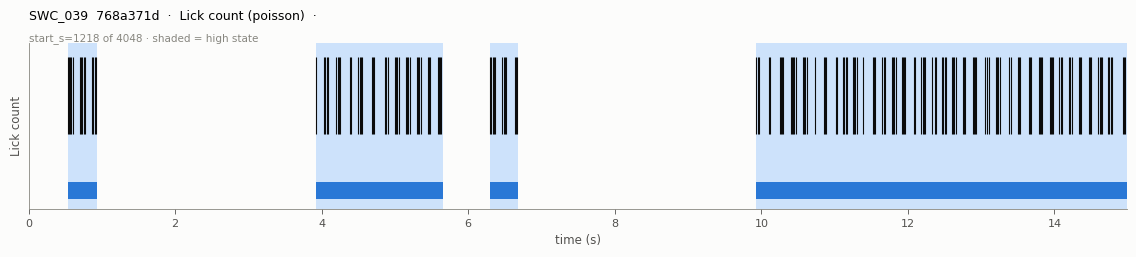

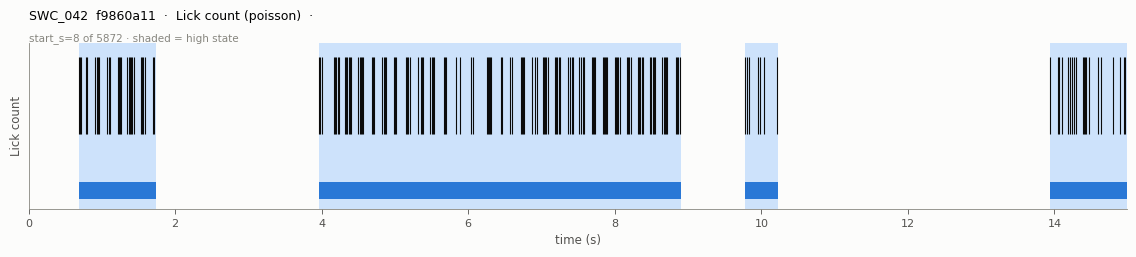

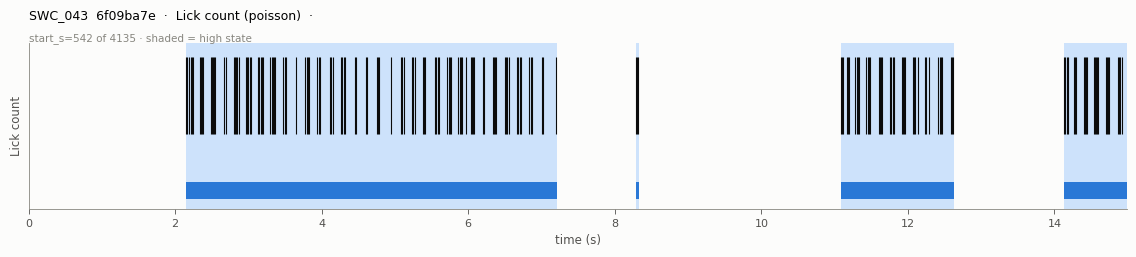

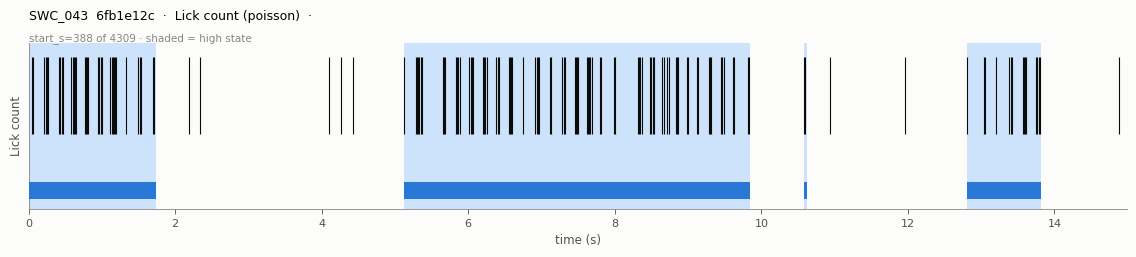

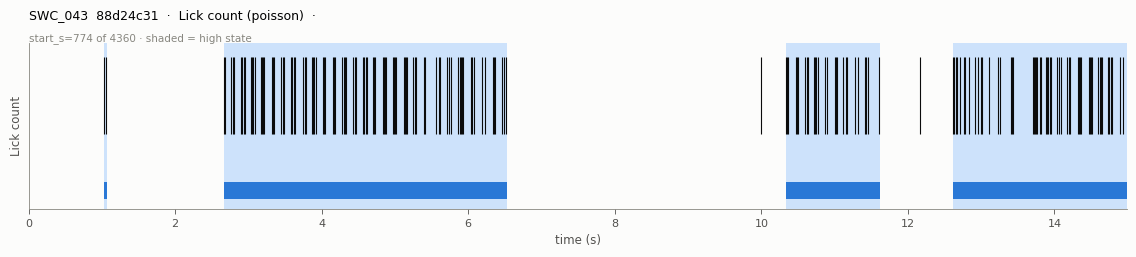

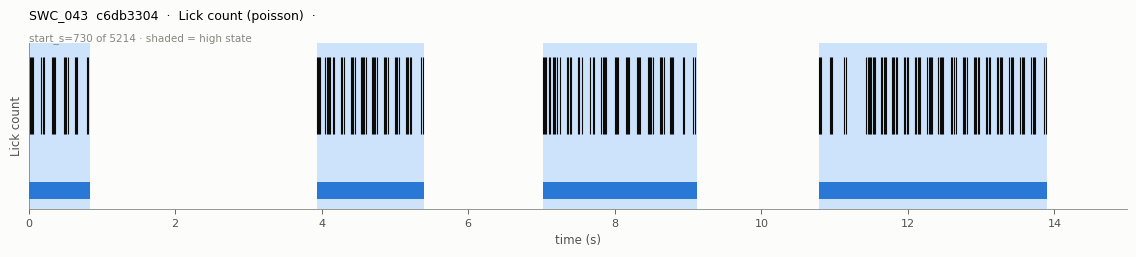

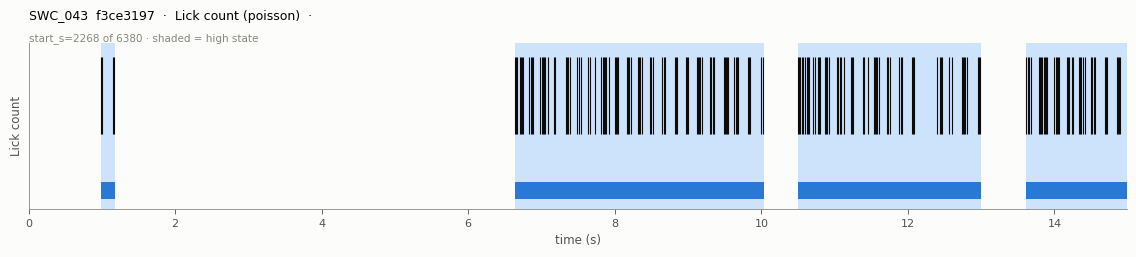

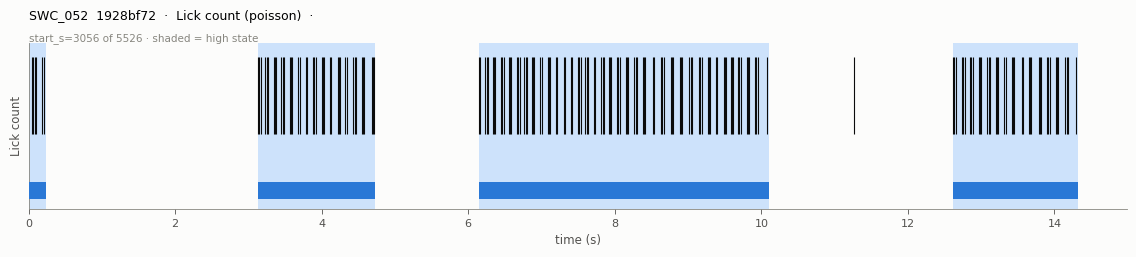

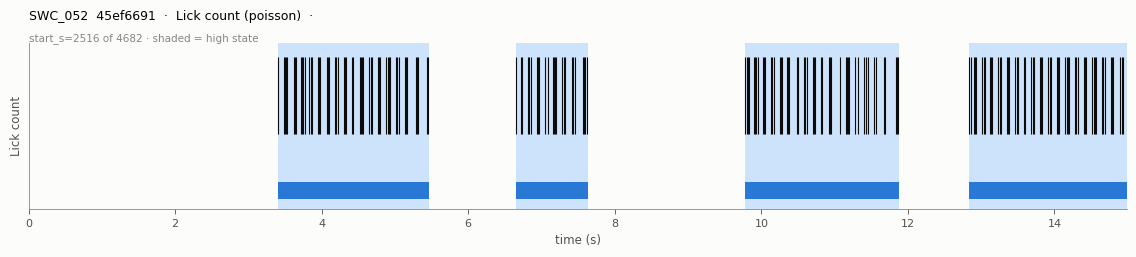

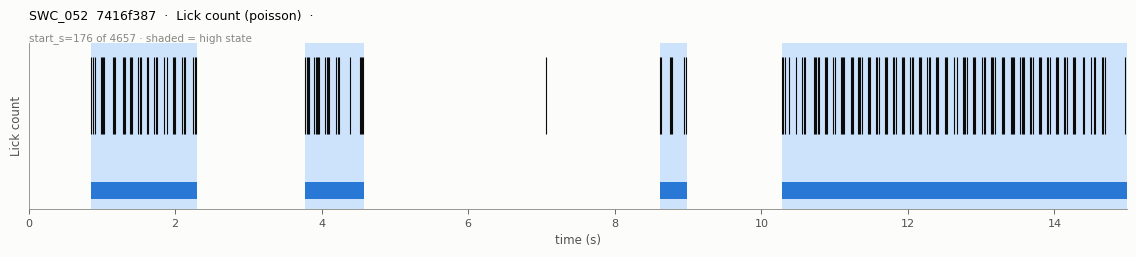

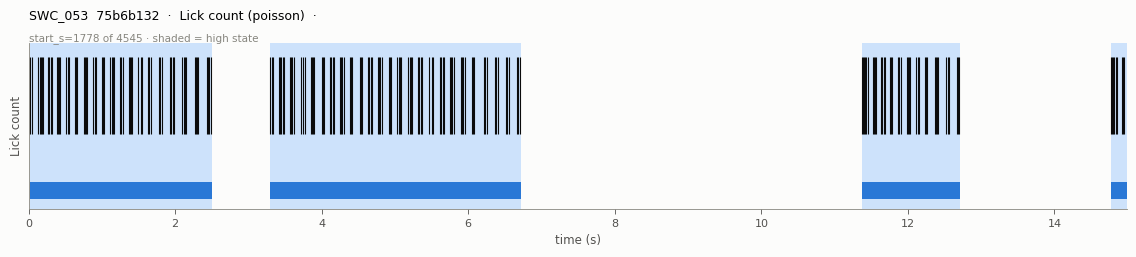

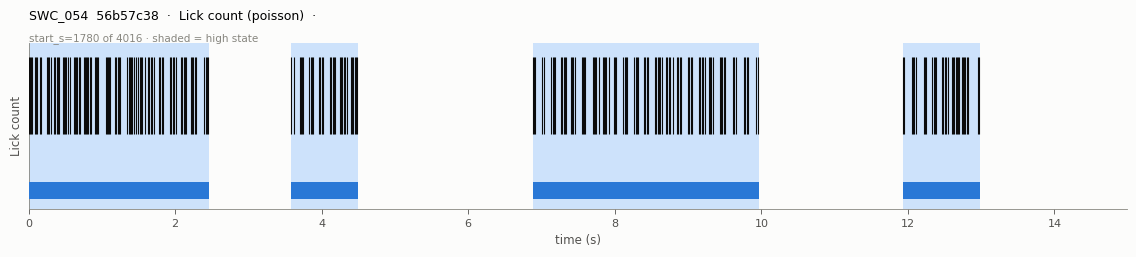

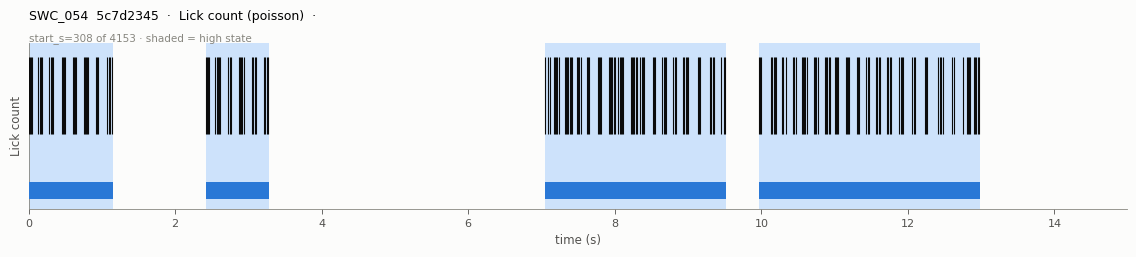

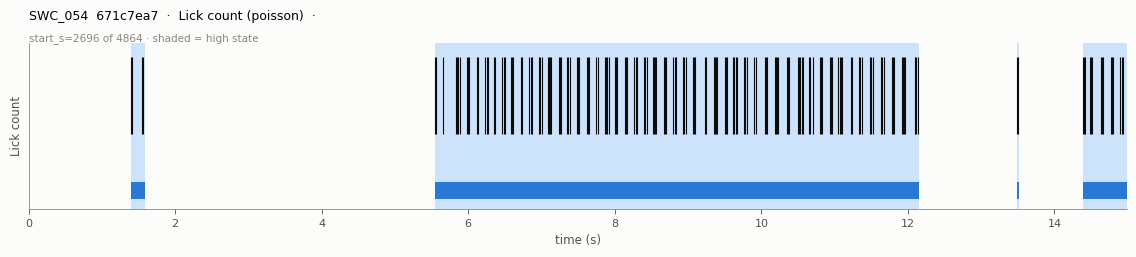

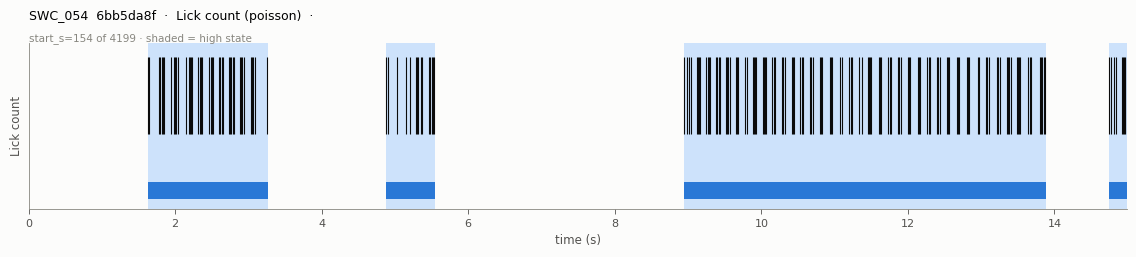

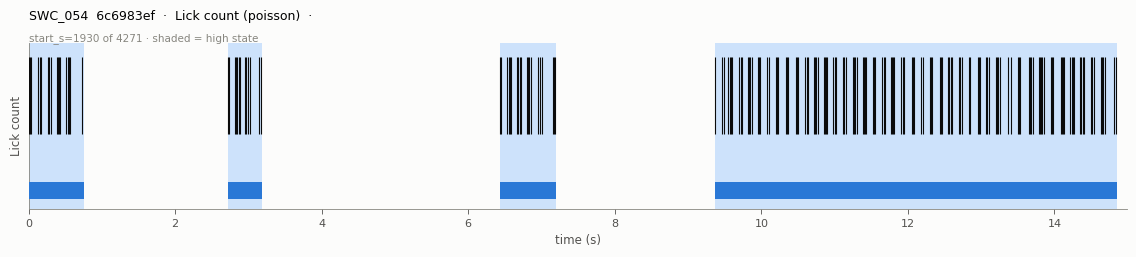

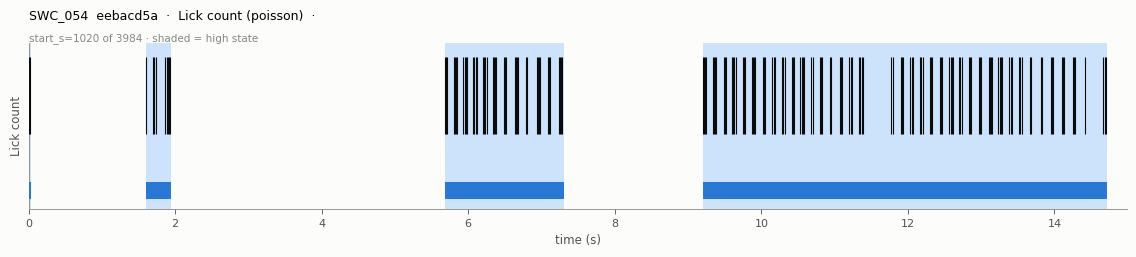

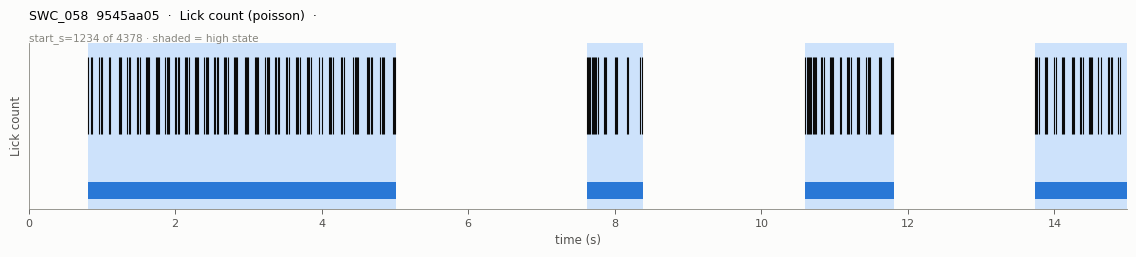

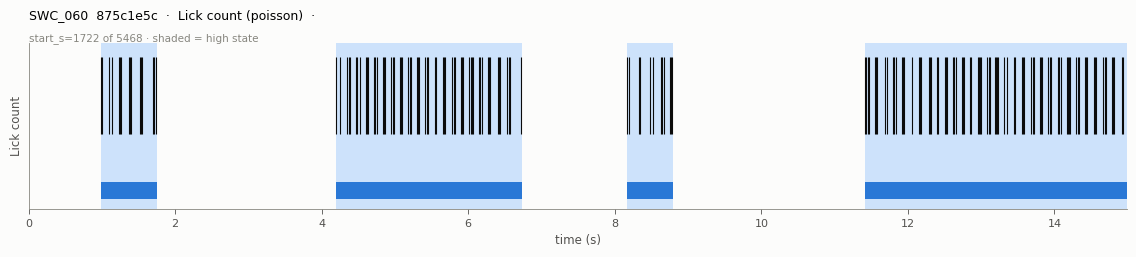

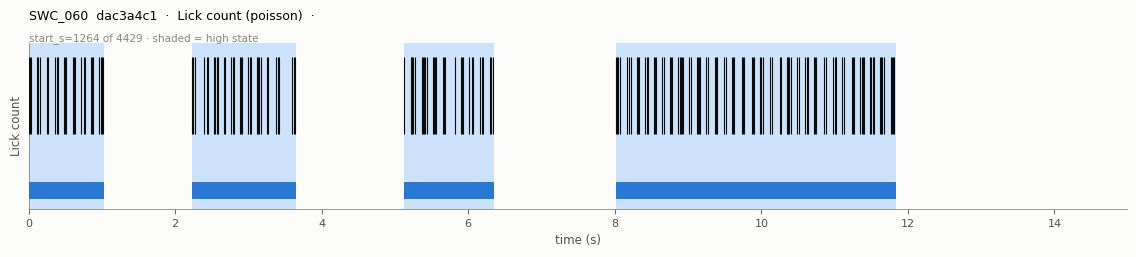

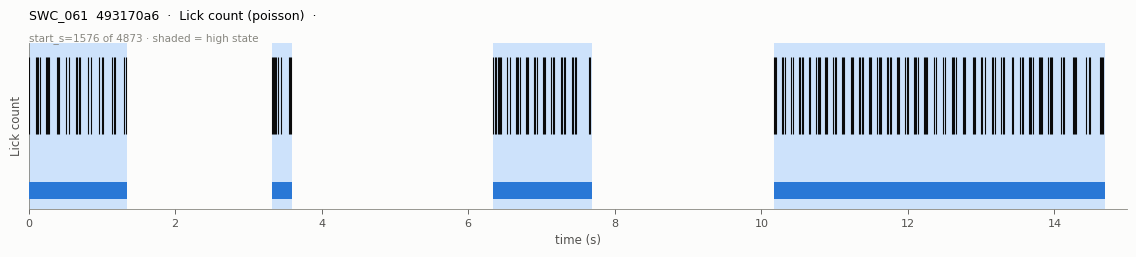

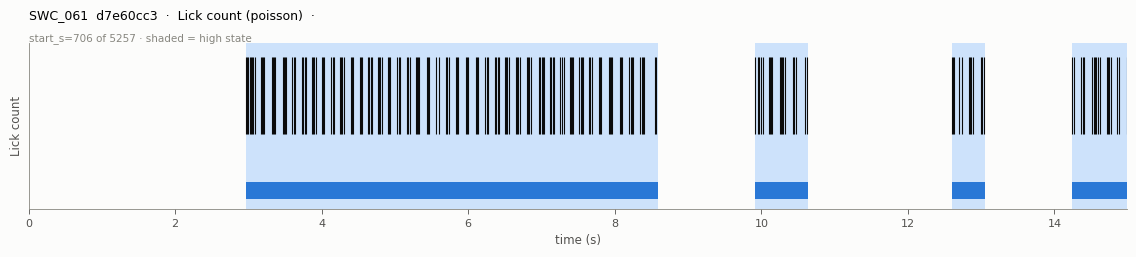

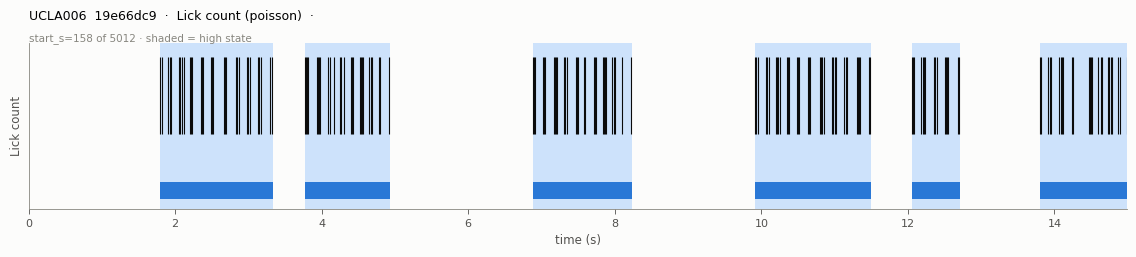

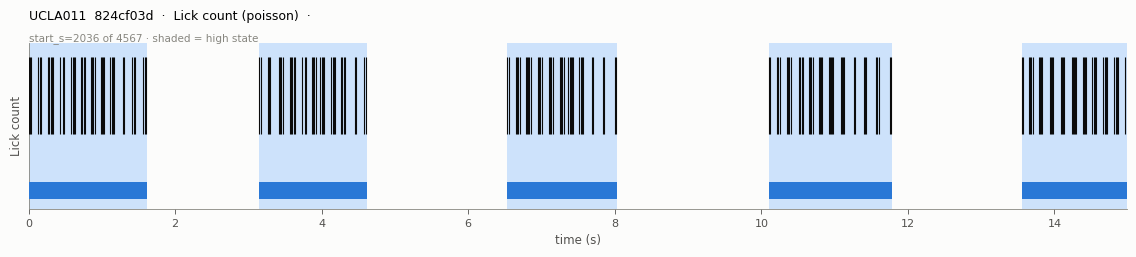

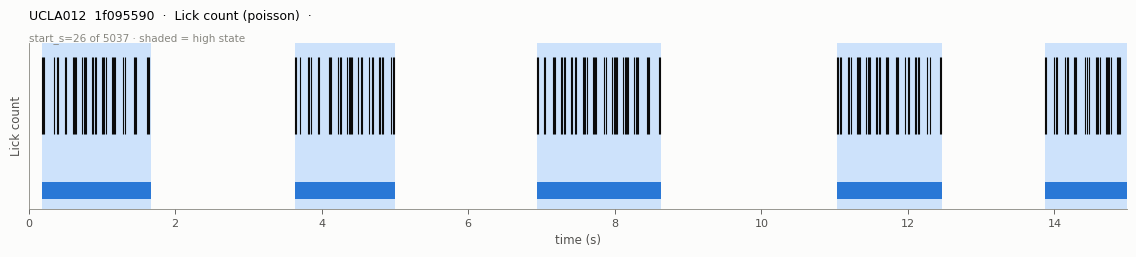

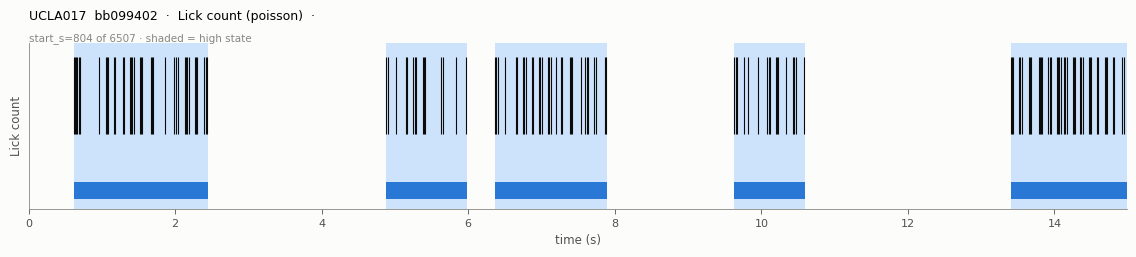

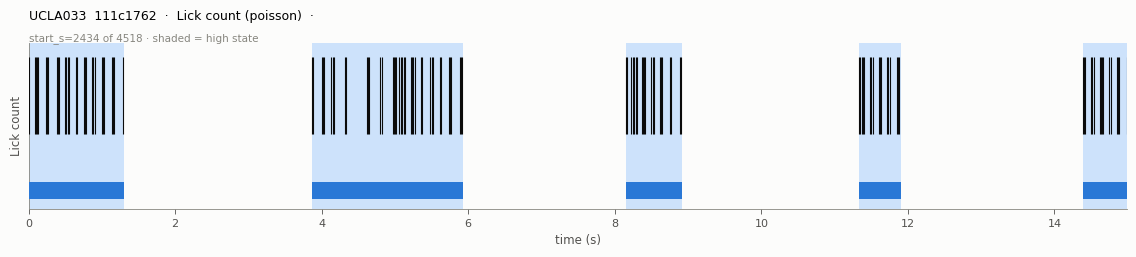

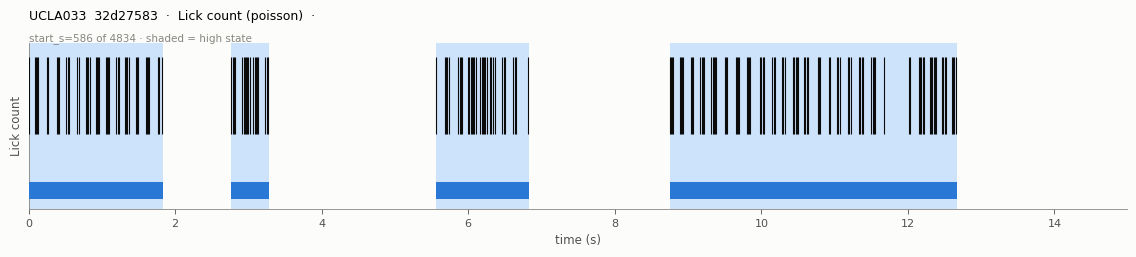

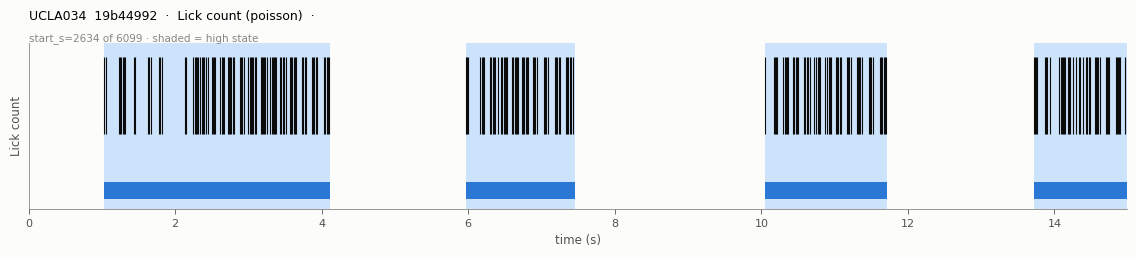

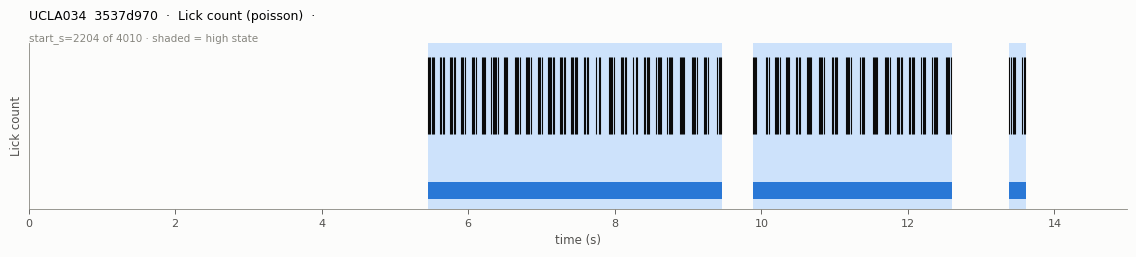

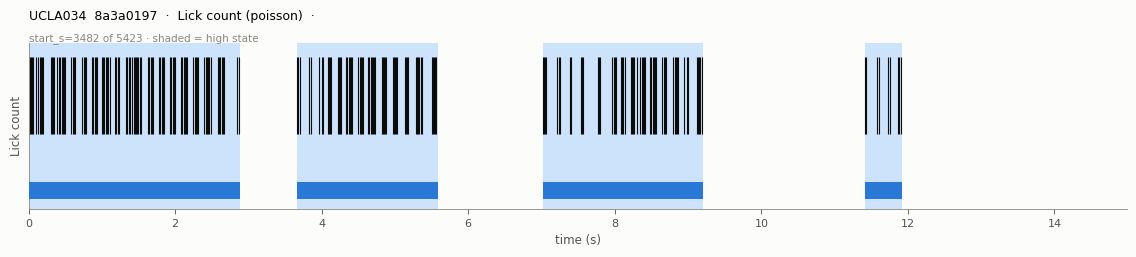

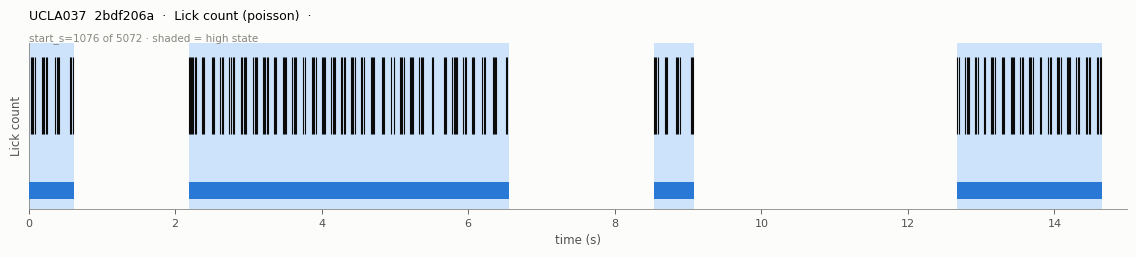

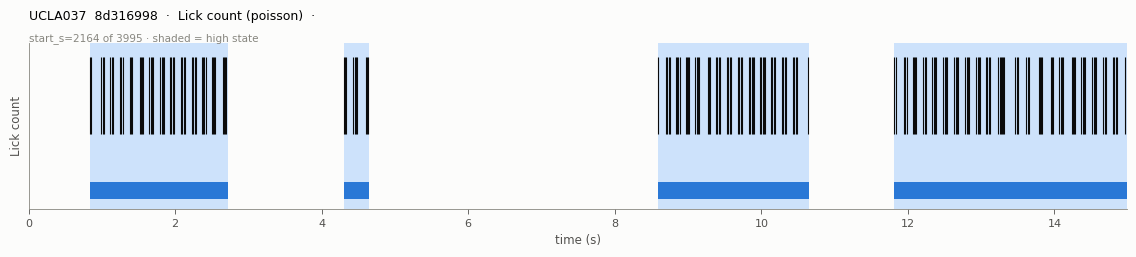

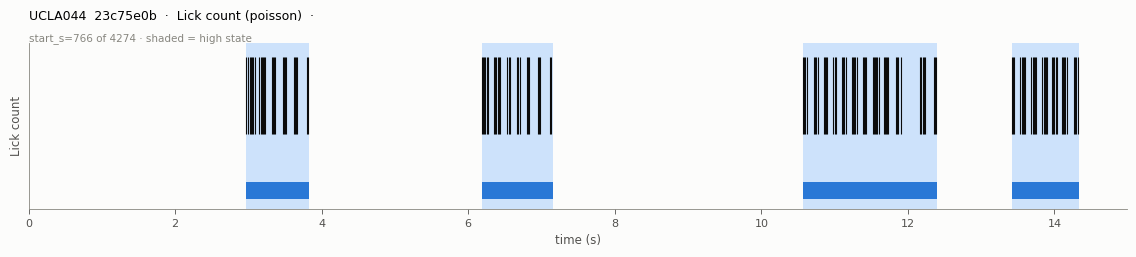

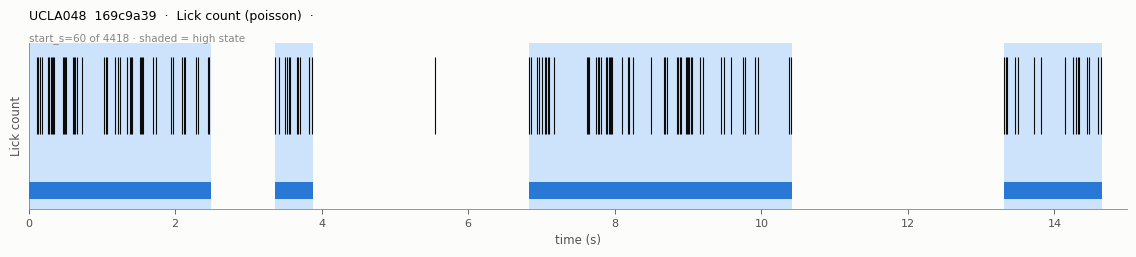

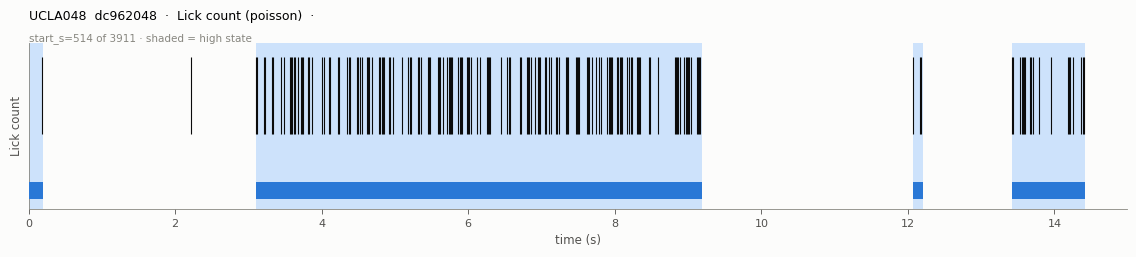

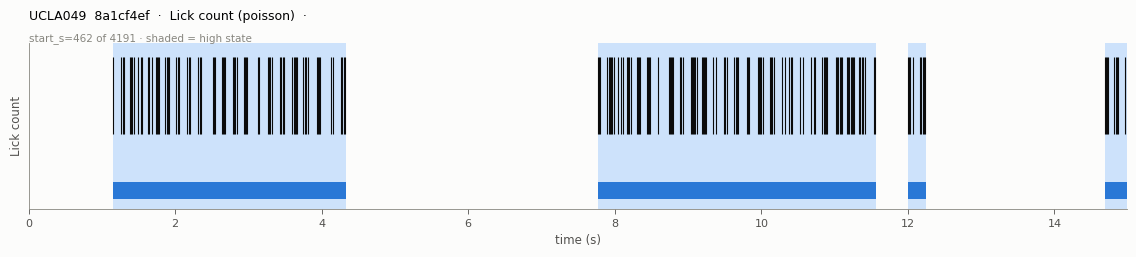

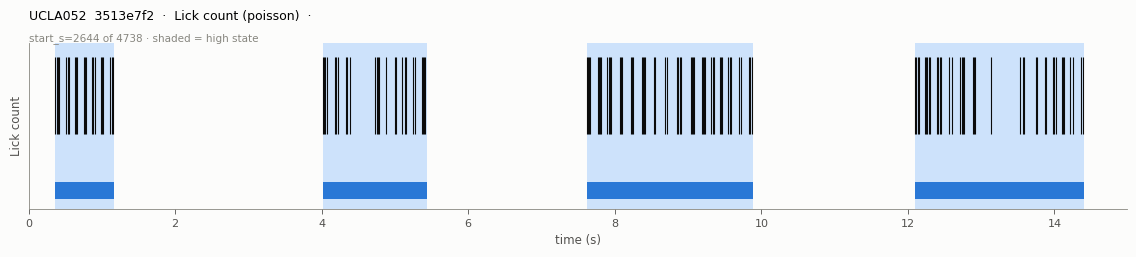

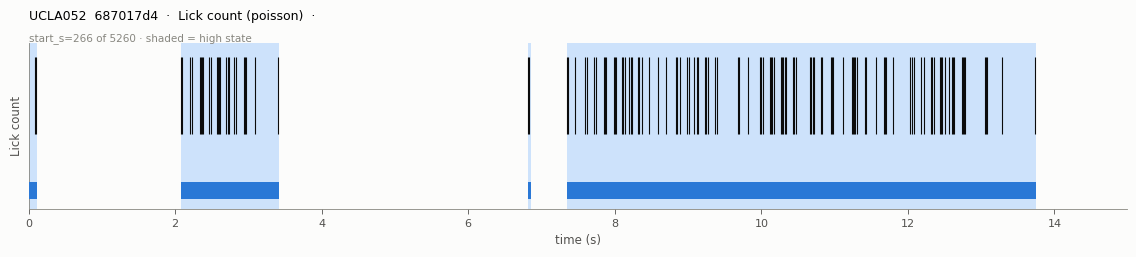

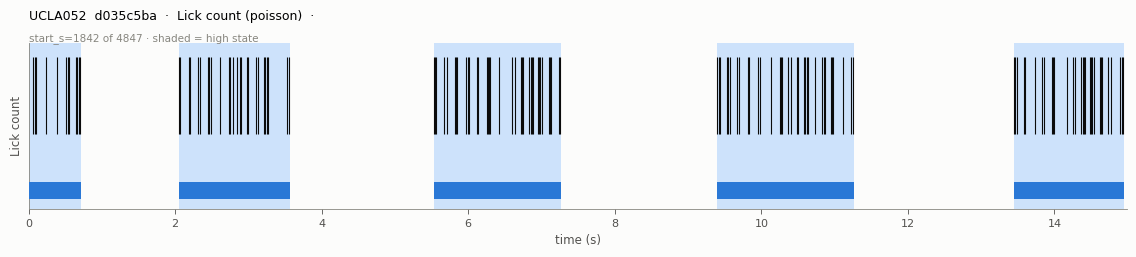

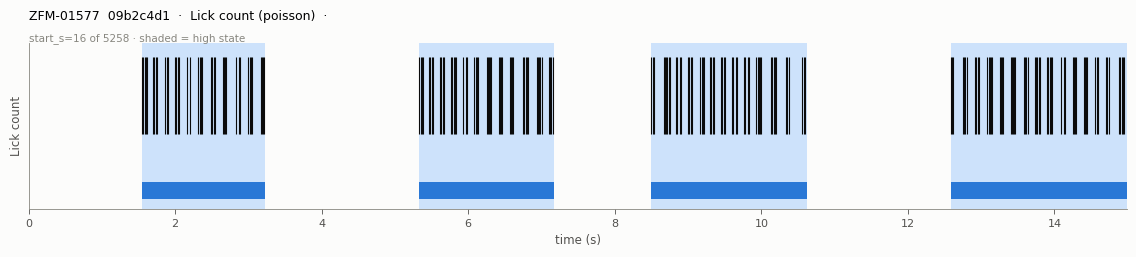

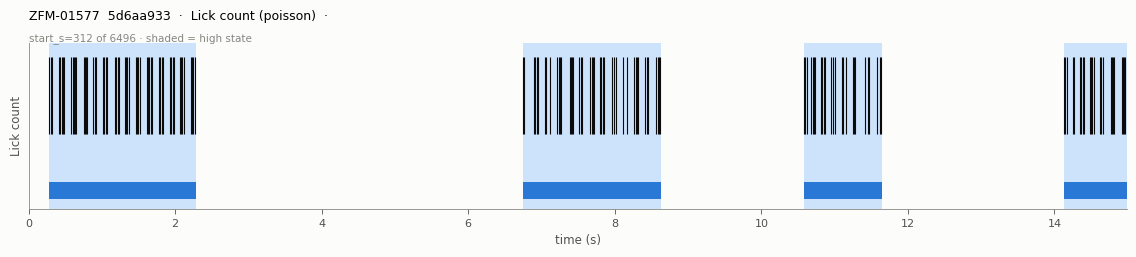

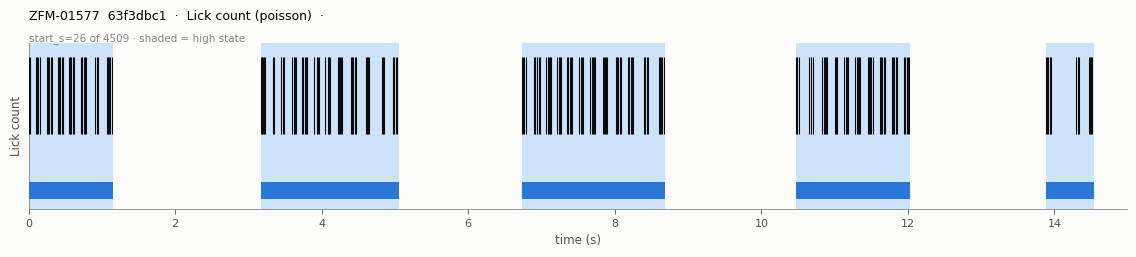

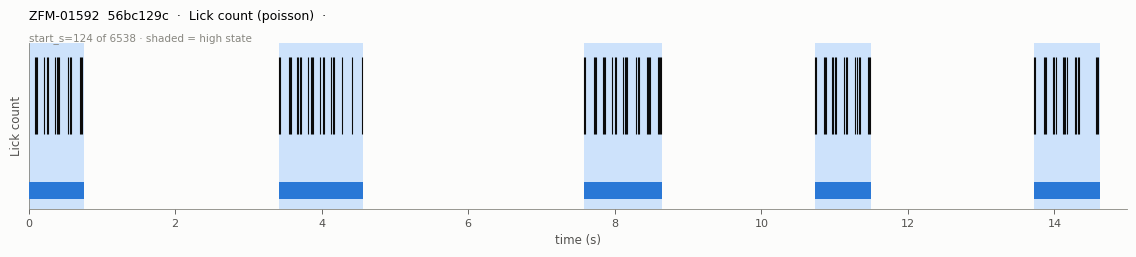

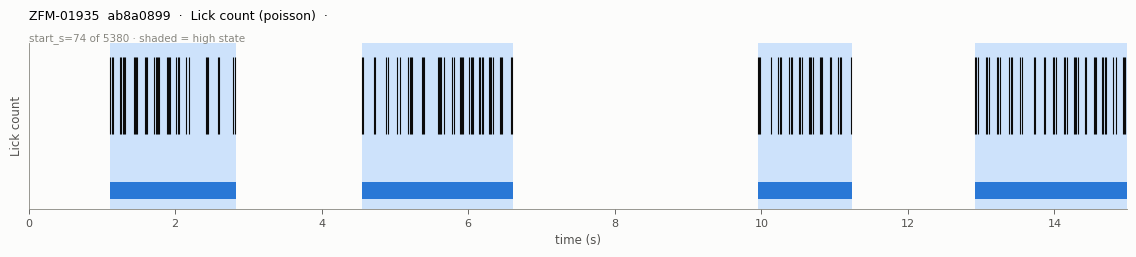

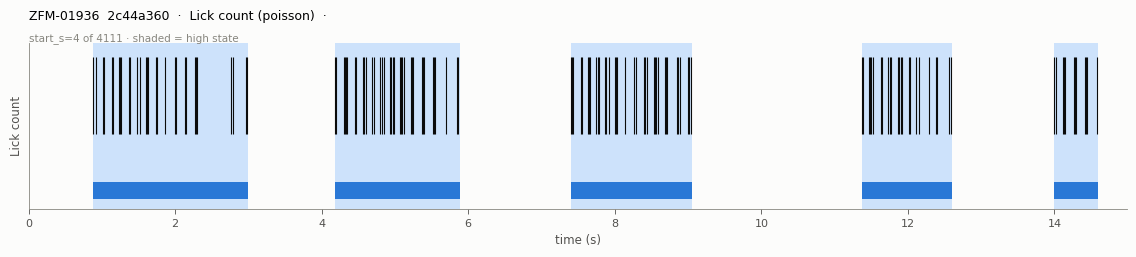

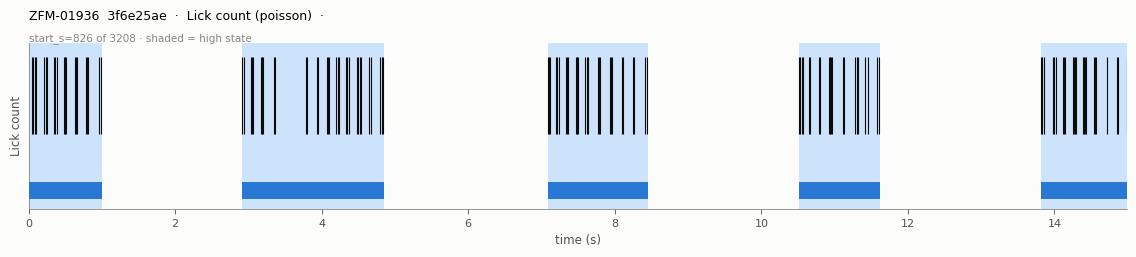

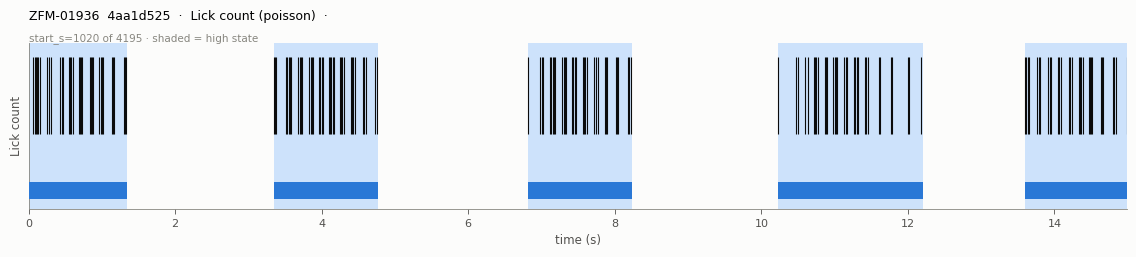

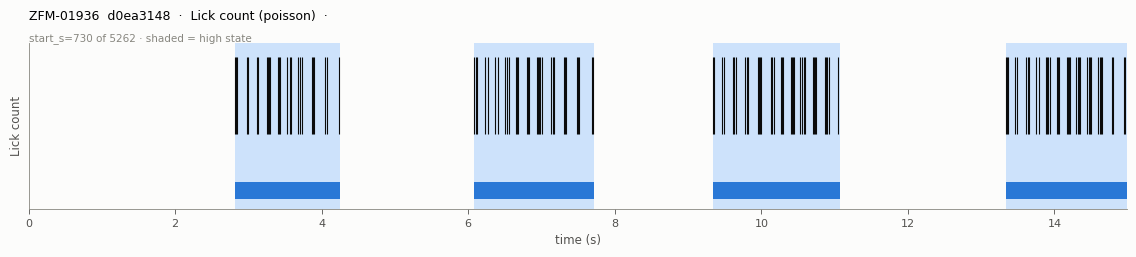

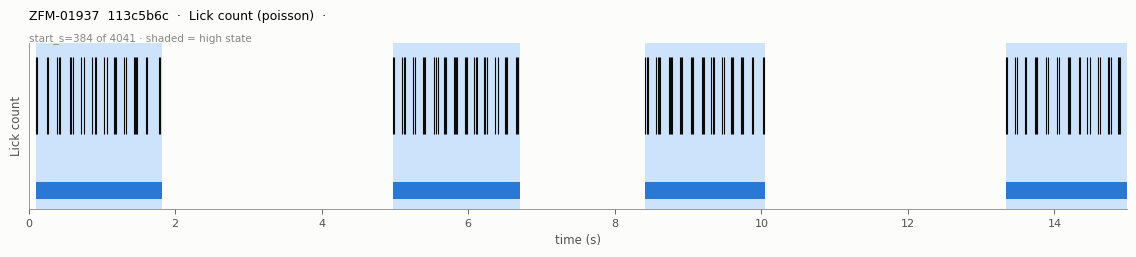

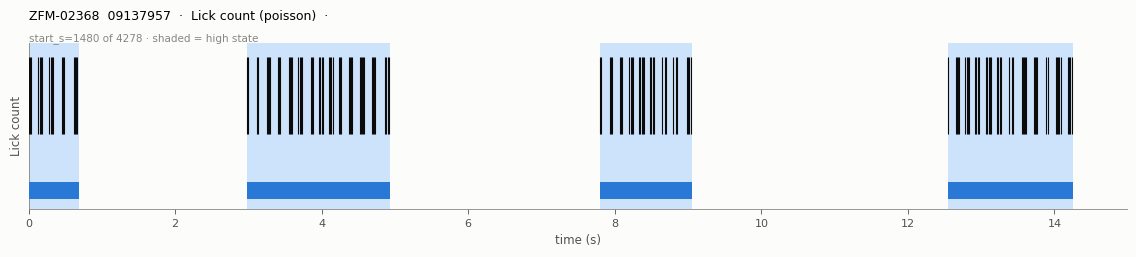

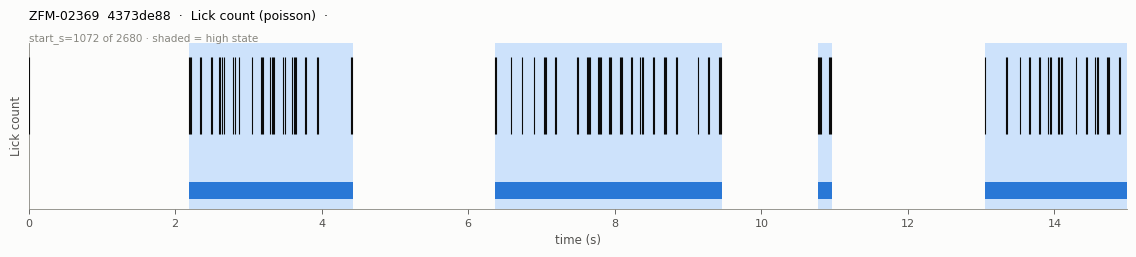

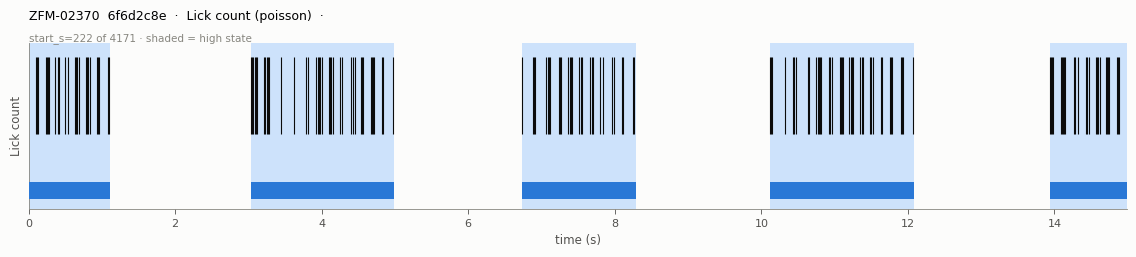

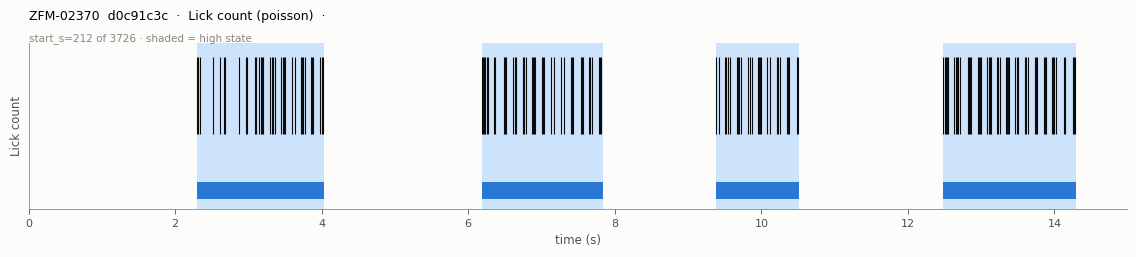

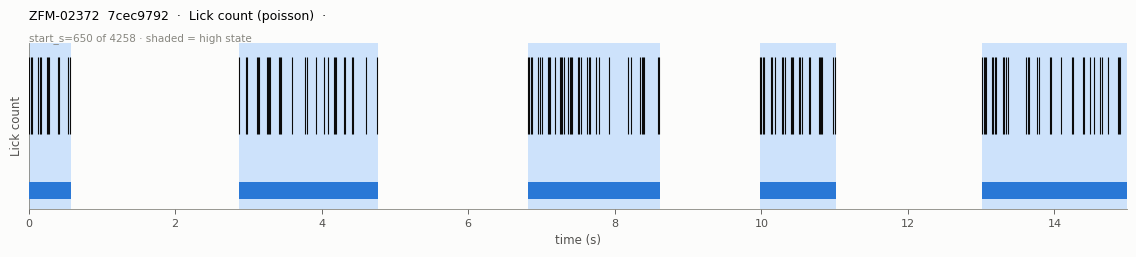

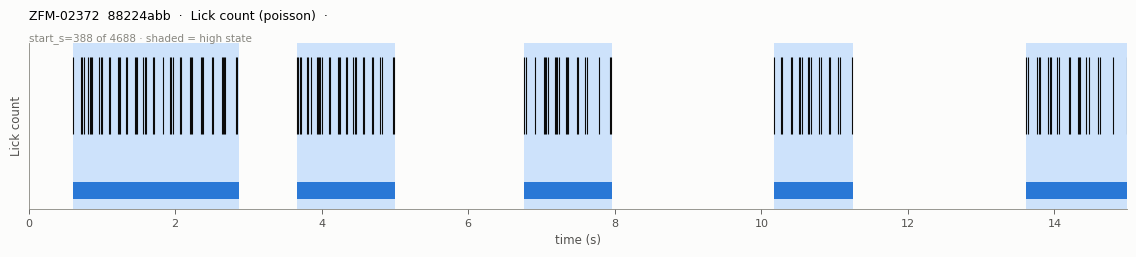

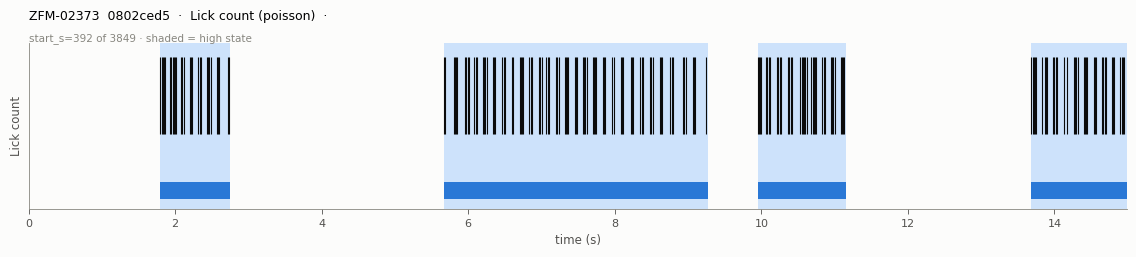

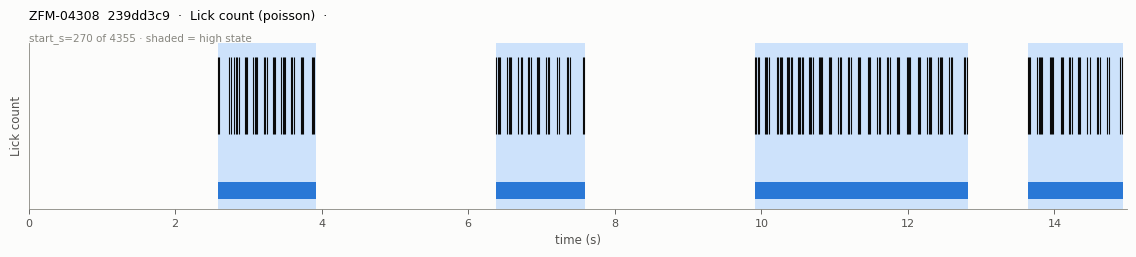

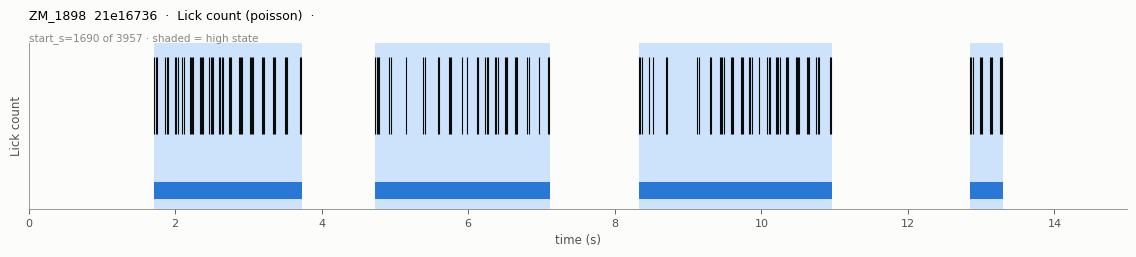

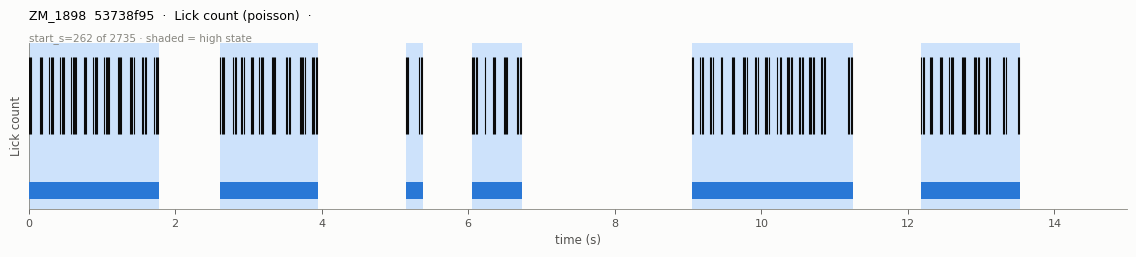

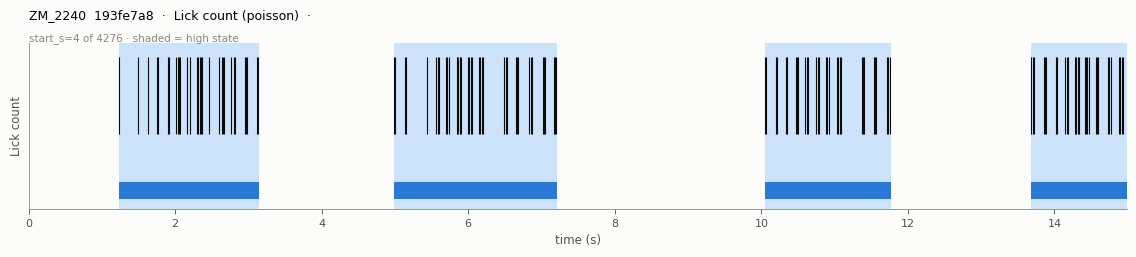

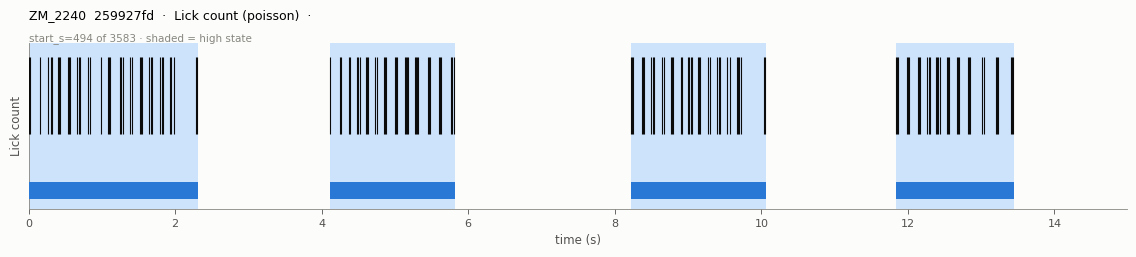

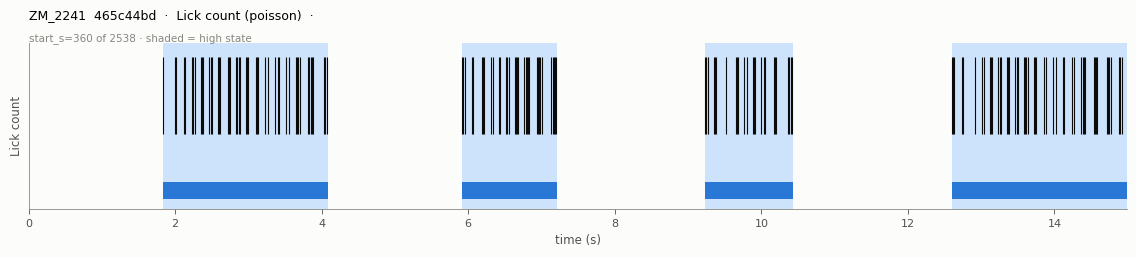

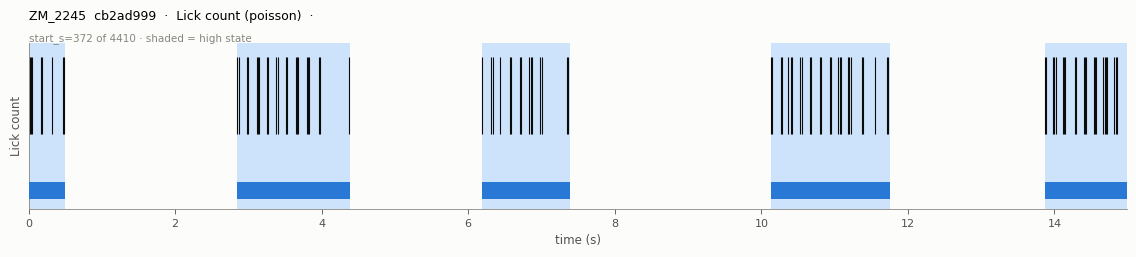

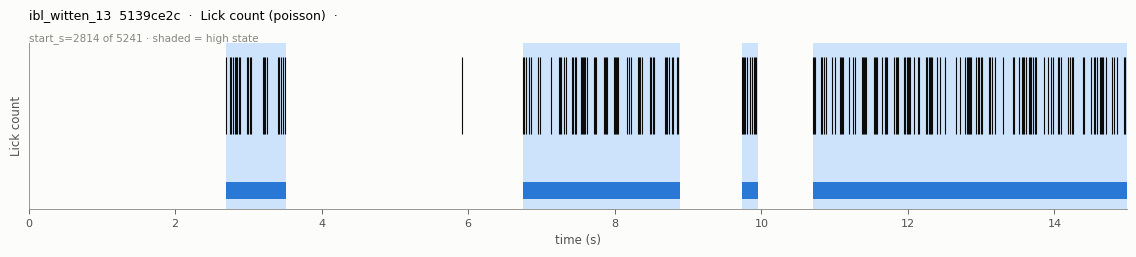

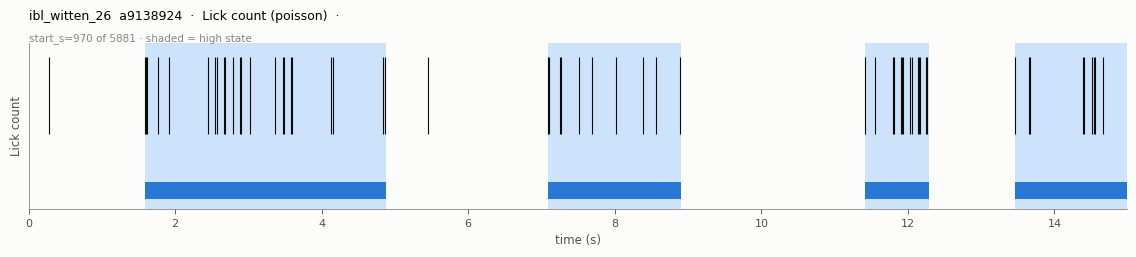

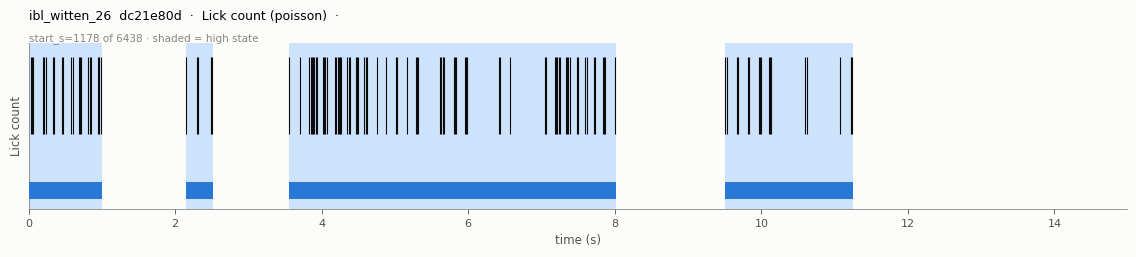

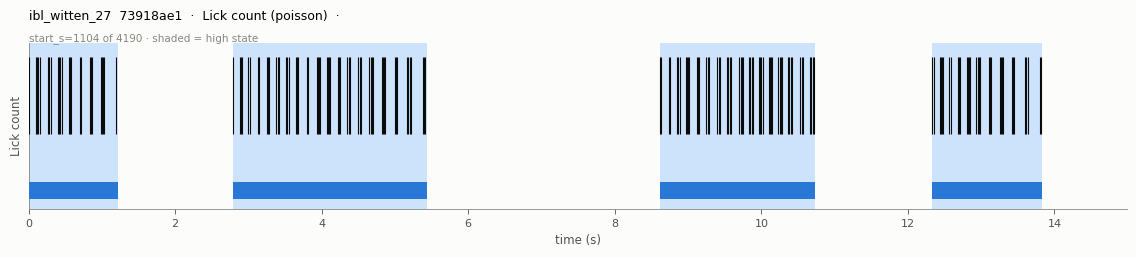

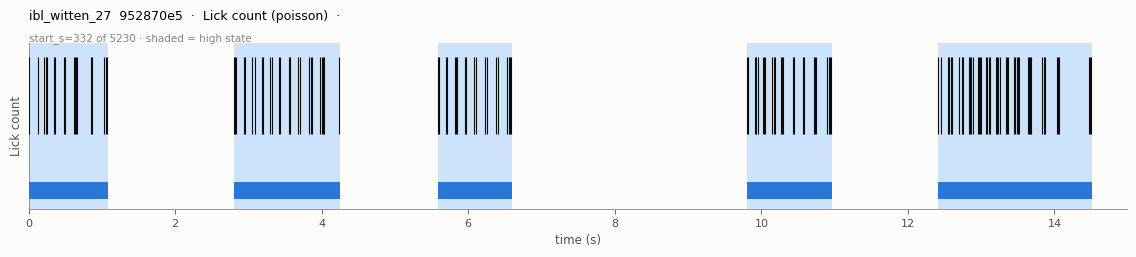

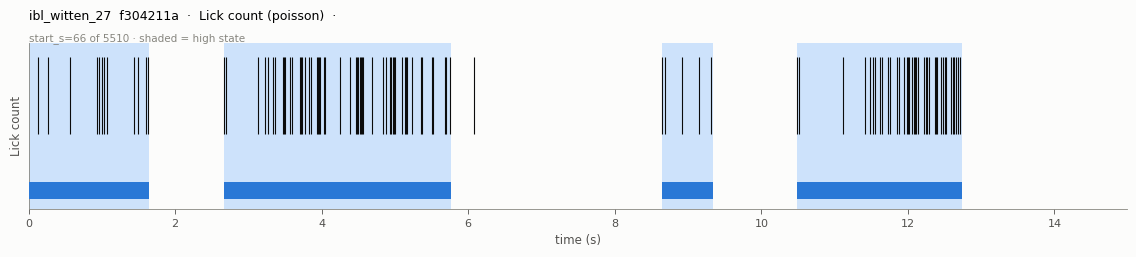

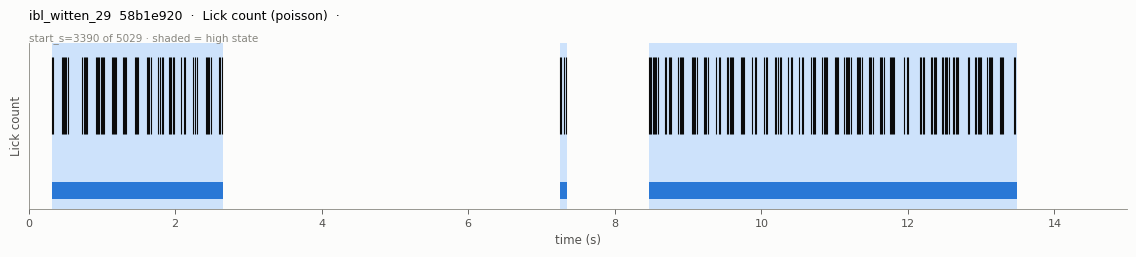

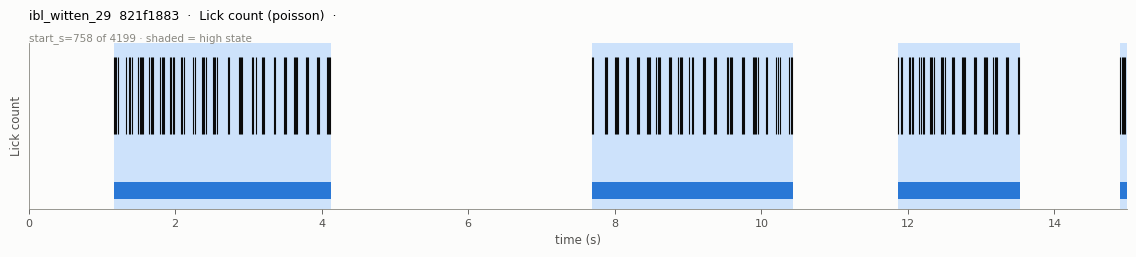

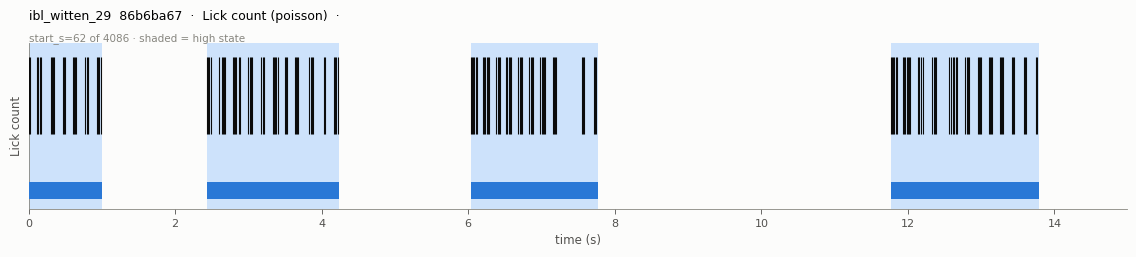

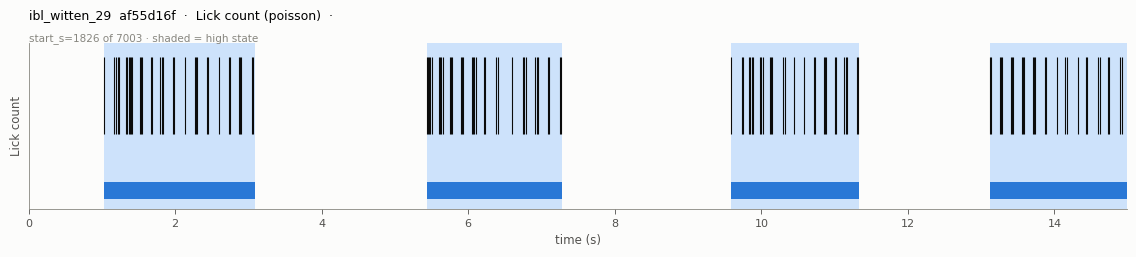

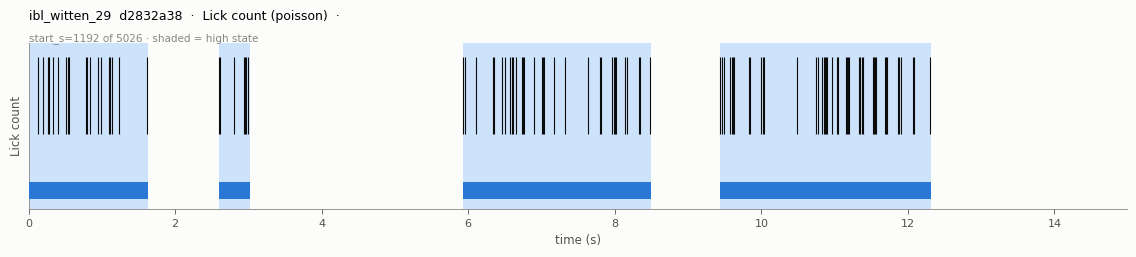

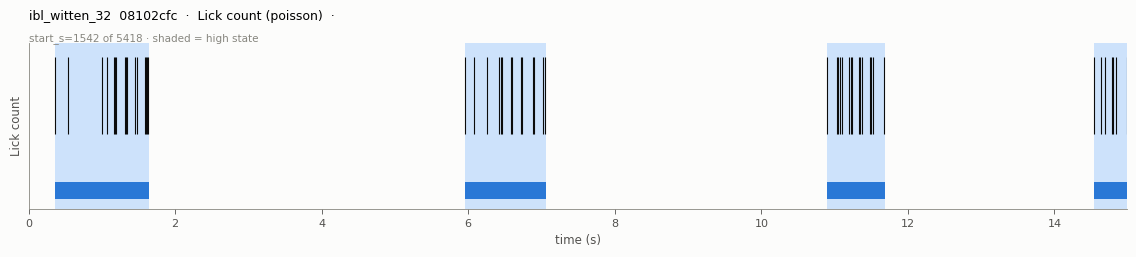

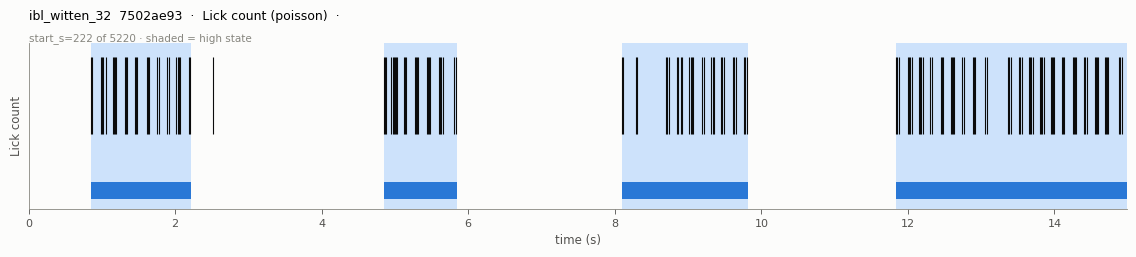

In [40]:
only_flagged = False
n_show = 200
win_s = 15
start_s = None

to_show = (df[~df.fit_ok] if only_flagged else df).head(n_show)
print(f'showing {len(to_show)} of {len(df)}')
for _, r in to_show.iterrows():
    try:
        fig, d = P.plot_session(save_path, data_path, var,
                                mouse_name=r['mouse'], session=r['eid'],
                                num_train_batches=num_train_batches, fps=fps,
                                win_s=win_s, start_s=start_s)
        plt.show()
    except FileNotFoundError as e:
        print(f"{r['mouse']} {r['eid'][:8]}: {e}")

## Compare the two variables on the same session

Whisking and licking segmented independently, on the same time axis — useful for sanity
(licking bouts should sit inside or beside whisking bouts, not at random).

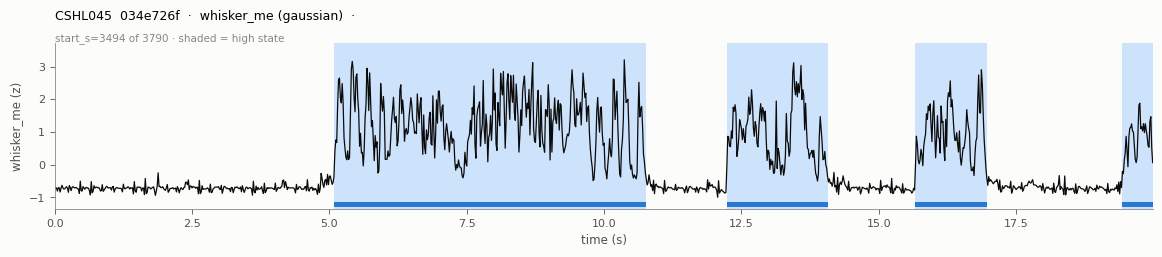

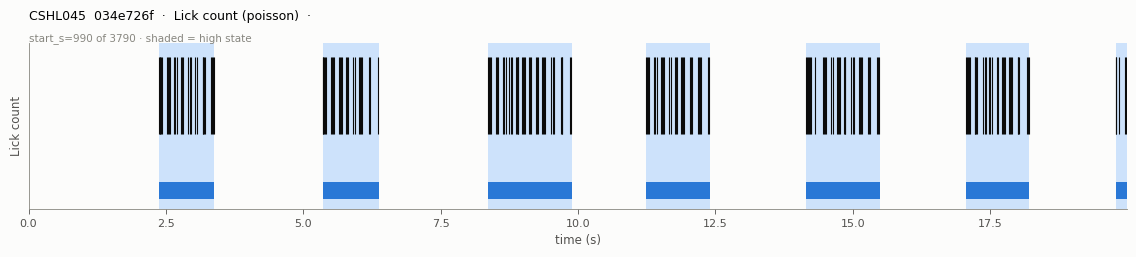

In [25]:
eid_both = df.iloc[0]['eid']

for spec_i in VARIABLES:
    sp, _ = paths_for(spec_i)
    try:
        fig, d = P.plot_session(sp, data_path, spec_i['var'], eid=eid_both,
                                num_train_batches=num_train_batches, fps=fps,
                                win_s=20, start_s=start_s)
        plt.show()
    except FileNotFoundError:
        print(f"{spec_i['var']}: not fitted for this session")